# Stage 2: Predictive Model — Backup Generator Detection
**Goal**: Using per-pixel NTL behavioral features to predict P(backup power present)  
**Label**: `in_buffer_strict` (weak proxy validated in Stage 1) — high/medium-signal facility types only  
**Key addition vs. original scheme**: facility-type category control + exclusion of weak-effect types  
**Validation**: Leave-One-Event-Out (LOEO)

---
> **Two label variants run in parallel:**
> - `in_buffer_strict` — hospital, aerodrome, power_plant, fire_station, police (main analysis)
> - `in_buffer` — all facility types including government/substation/water_works (sensitivity check)


## 0. Imports & Setup

In [160]:
import os, glob, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from scipy.spatial import cKDTree
from shapely.geometry import Point

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.model_selection import train_test_split
import xgboost as xgb
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

print("All imports OK")


All imports OK


## 1. Configuration
All paths, event metadata, facility type groups, model hyperparameters.

In [161]:
# ─── Paths ───────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath("")
_candidate   = os.path.dirname(NOTEBOOK_DIR)
PROJECT_ROOT = _candidate if os.path.isdir(os.path.join(_candidate, "data")) else NOTEBOOK_DIR

DATA_DIR   = os.path.join(PROJECT_ROOT, "data", "processed")
RESULT_DIR = os.path.join(PROJECT_ROOT, "data", "result")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data", "result", "stage2")
os.makedirs(OUTPUT_DIR, exist_ok=True)

PANEL_CACHE = os.path.join(OUTPUT_DIR, "pixel_panel.parquet")

# ─── Always delete cache to force rebuild with correct CRS ──────────────────────
if os.path.exists(PANEL_CACHE):
    os.remove(PANEL_CACHE)
    print(f"Deleted stale cache: {PANEL_CACHE}")

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}   exists={os.path.isdir(DATA_DIR)}")


Deleted stale cache: /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/pixel_panel.parquet
PROJECT_ROOT : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project
DATA_DIR     : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/processed   exists=True


In [162]:
# ─── Facility Type Groups ─────────────────────────────────────────────────────
HIGH_SIGNAL_TYPES   = ["hospital", "aerodrome", "power_plant"]
MEDIUM_SIGNAL_TYPES = ["fire_station", "police"]
EXCLUDED_TYPES      = ["government", "substation", "water_works"]
ALL_SIGNAL_TYPES    = HIGH_SIGNAL_TYPES + MEDIUM_SIGNAL_TYPES

FACILITY_GROUP = {
    "hospital": 1, "aerodrome": 1, "power_plant": 1,
    "fire_station": 2, "police": 2,
    "government": 3, "substation": 3, "water_works": 3,
}
BUFFER_RADIUS = {"aerodrome": 1250, "default": 750}
MIN_PRE_NTL   = 0.5

# ─── Event Configuration (9 events) ──────────────────────────────────────────
EVENTS = {
    # ── Original 6 ────────────────────────────────────────────────────────────
    "Maria_SanJuan": {
        "pre": "Maria-VNP46A2-pre", "post": "Maria-VNP46A2-post",
        "city": "San Juan", "disaster_type": "hurricane", "city_size": "large",
        "bbox": (18.35, -66.20, 18.48, -65.95), "utm_crs": "EPSG:32619",
    },
    "Irma_Miami": {
        "pre": "Irma_Miami-VNP46A2-pre", "post": "Irma_Miami-VNP46A2-post",
        "city": "Miami", "disaster_type": "hurricane", "city_size": "large",
        "bbox": (25.70, -80.40, 25.90, -80.10), "utm_crs": "EPSG:32617",
    },
    "Ida_NewOrleans": {
        "pre": "Ida_NewOrleans-VNP46A2-pre", "post": "Ida_NewOrleans-VNP46A2-post",
        "city": "New Orleans", "disaster_type": "hurricane", "city_size": "large",
        "bbox": (29.87, -90.20, 30.08, -89.90), "utm_crs": "EPSG:32615",
    },
    "Laura_LakeCharles": {
        "pre": "Laura_LakeCharles-VNP46A2-pre", "post": "Laura_LakeCharles-VNP46A2-post",
        "city": "Lake Charles", "disaster_type": "hurricane", "city_size": "small",
        "bbox": (30.15, -93.35, 30.30, -93.10), "utm_crs": "EPSG:32615",
    },
    "Michael_PanamaCity": {
        "pre": "Michael-VNP46A2-pre", "post": "Michael-VNP46A2-post",
        "city": "Panama City", "disaster_type": "hurricane", "city_size": "small",
        "bbox": (30.10, -85.80, 30.25, -85.55), "utm_crs": "EPSG:32616",
    },
    "Earthquake_SanJuan": {
        "pre": "Earthquake-VNP46A2-pre", "post": "Earthquake-VNP46A2-post",
        "city": "San Juan", "disaster_type": "earthquake", "city_size": "large",
        "bbox": (18.35, -66.20, 18.48, -65.95), "utm_crs": "EPSG:32619",
    },
    # ── New events (from existing data folders) ────────────────────────────────
    "Ian_CharlotteHarbor": {
        "pre": "Ian_CharlotteHarbor-VNP46A2-pre",
        "post": "Ian_CharlotteHarbor-VNP46A2-post",
        "city": "Charlotte Harbor", "disaster_type": "hurricane", "city_size": "small",
        "bbox": (26.85, -82.20, 27.05, -81.95), "utm_crs": "EPSG:32617",
    },
    "Ian_FortMyers": {
        "pre": "Ian_FortMyers-VNP46A2-pre",
        "post": "Ian_FortMyers-VNP46A2-post",
        "city": "Fort Myers", "disaster_type": "hurricane", "city_size": "medium",
        "bbox": (26.50, -81.95, 26.70, -81.75), "utm_crs": "EPSG:32617",
    },
    "Earthquake_Hatay": {
        "pre": "Earthquake_Hatay-VNP46A2-pre",
        "post": "Earthquake_Hatay-VNP46A2-post",
        "city": "Hatay", "disaster_type": "earthquake", "city_size": "medium",
        "bbox": (36.10, 36.00, 36.50, 36.50), "utm_crs": "EPSG:32637",
    },
    # ── Stage 3 new events (6 downloaded so far) ──────────────────────
    "Florence_Wilmington": {
        "pre": "Florence_Wilmington-VNP46A2-pre", "post": "Florence_Wilmington-VNP46A2-post",
        "city": "Wilmington", "disaster_type": "hurricane", "city_size": "small",
        "bbox": (34.08, -78.125, 34.38, -77.775), "utm_crs": "EPSG:32618",
    },
    "Irma_Savannah": {
        "pre": "Irma_Savannah-VNP46A2-pre", "post": "Irma_Savannah-VNP46A2-post",
        "city": "Savannah", "disaster_type": "hurricane", "city_size": "medium",
        "bbox": (31.93, -81.265, 32.23, -80.915), "utm_crs": "EPSG:32617",
    },
    "Isaias_Newark": {
        "pre": "Isaias_Newark-VNP46A2-pre", "post": "Isaias_Newark-VNP46A2-post",
        "city": "Newark", "disaster_type": "hurricane", "city_size": "large",
        "bbox": (40.59, -74.345, 40.89, -73.995), "utm_crs": "EPSG:32618",
    },
    "Matthew_Jacksonville": {
        "pre": "Matthew_Jacksonville-VNP46A2-pre", "post": "Matthew_Jacksonville-VNP46A2-post",
        "city": "Jacksonville", "disaster_type": "hurricane", "city_size": "large",
        "bbox": (30.18, -81.835, 30.48, -81.485), "utm_crs": "EPSG:32617",
    },
    "Zeta_Atlanta": {
        "pre": "Zeta_Atlanta-VNP46A2-pre", "post": "Zeta_Atlanta-VNP46A2-post",
        "city": "Atlanta", "disaster_type": "hurricane", "city_size": "large",
        "bbox": (33.6, -84.565, 33.9, -84.215), "utm_crs": "EPSG:32616",
    },
    "Zeta_Birmingham": {
        "pre": "Zeta_Birmingham-VNP46A2-pre", "post": "Zeta_Birmingham-VNP46A2-post",
        "city": "Birmingham", "disaster_type": "hurricane", "city_size": "medium",
        "bbox": (33.37, -86.975, 33.67, -86.625), "utm_crs": "EPSG:32616",
    },
    # ── Stage 3 batch 2 (10 more events) ──────────────────────────────────
    "Matthew_Fayetteville": {
        "pre": "Matthew_Fayetteville-VNP46A2-pre", "post": "Matthew_Fayetteville-VNP46A2-post",
        "city": "Fayetteville", "disaster_type": "hurricane", "city_size": "small",
        "bbox": (34.91, -79.055, 35.21, -78.705), "utm_crs": "EPSG:32617",
    },
    "Florence_MyrtleBeach": {
        "pre": "Florence_MyrtleBeach-VNP46A2-pre", "post": "Florence_MyrtleBeach-VNP46A2-post",
        "city": "Myrtle Beach", "disaster_type": "hurricane", "city_size": "small",
        "bbox": (33.54, -79.065, 33.84, -78.715), "utm_crs": "EPSG:32617",
    },
    "Isaias_Westchester": {
        "pre": "Isaias_Westchester-VNP46A2-pre", "post": "Isaias_Westchester-VNP46A2-post",
        "city": "Westchester", "disaster_type": "hurricane", "city_size": "medium",
        "bbox": (40.88, -73.935, 41.18, -73.585), "utm_crs": "EPSG:32618",
    },
    "Uri_Houston": {
        "pre": "Uri_Houston-VNP46A2-pre", "post": "Uri_Houston-VNP46A2-post",
        "city": "Houston", "disaster_type": "winter_storm", "city_size": "large",
        "bbox": (29.61, -95.545, 29.91, -95.195), "utm_crs": "EPSG:32615",
    },
    "Derecho_Chicago": {
        "pre": "Derecho_Chicago-VNP46A2-pre", "post": "Derecho_Chicago-VNP46A2-post",
        "city": "Chicago", "disaster_type": "derecho", "city_size": "large",
        "bbox": (41.73, -87.805, 42.03, -87.455), "utm_crs": "EPSG:32616",
    },
    "Severe_Detroit": {
        "pre": "Severe_Detroit-VNP46A2-pre", "post": "Severe_Detroit-VNP46A2-post",
        "city": "Detroit", "disaster_type": "severe_storm", "city_size": "large",
        "bbox": (42.18, -83.225, 42.48, -82.875), "utm_crs": "EPSG:32617",
    },
    "Noreaster_Boston": {
        "pre": "Noreaster_Boston-VNP46A2-pre", "post": "Noreaster_Boston-VNP46A2-post",
        "city": "Boston", "disaster_type": "winter_storm", "city_size": "large",
        "bbox": (42.21, -71.235, 42.51, -70.885), "utm_crs": "EPSG:32619",
    },
    "IceStorm_OKC": {
        "pre": "IceStorm_OKC-VNP46A2-pre", "post": "IceStorm_OKC-VNP46A2-post",
        "city": "Oklahoma City", "disaster_type": "ice_storm", "city_size": "medium",
        "bbox": (35.32, -97.695, 35.62, -97.345), "utm_crs": "EPSG:32614",
    },
    "Severe_Nashville": {
        "pre": "Severe_Nashville-VNP46A2-pre", "post": "Severe_Nashville-VNP46A2-post",
        "city": "Nashville", "disaster_type": "severe_storm", "city_size": "medium",
        "bbox": (36.01, -86.955, 36.31, -86.605), "utm_crs": "EPSG:32616",
    },
    "Atmos_Seattle": {
        "pre": "Atmos_Seattle-VNP46A2-pre", "post": "Atmos_Seattle-VNP46A2-post",
        "city": "Seattle", "disaster_type": "winter_storm", "city_size": "large",
        "bbox": (47.46, -122.505, 47.76, -122.155), "utm_crs": "EPSG:32610",
    },

}

print(f"Total events configured: {len(EVENTS)}")
print(f"{'Event':25s}  {'City':20s}  {'Type':12s}  {'Size':8s}")
print("-" * 70)
for k, v in EVENTS.items():
    marker = " ← NEW" if k in ("Ian_CharlotteHarbor","Ian_FortMyers","Earthquake_Hatay","Florence_Wilmington","Irma_Savannah","Isaias_Newark","Matthew_Jacksonville","Zeta_Atlanta","Zeta_Birmingham") else ""
    print(f"{k:25s}  {v['city']:20s}  {v['disaster_type']:12s}  {v['city_size']:8s}{marker}")


Total events configured: 9
Event                      City                  Type          Size    
----------------------------------------------------------------------
Maria_SanJuan              San Juan              hurricane     large   
Irma_Miami                 Miami                 hurricane     large   
Ida_NewOrleans             New Orleans           hurricane     large   
Laura_LakeCharles          Lake Charles          hurricane     small   
Michael_PanamaCity         Panama City           hurricane     small   
Earthquake_SanJuan         San Juan              earthquake    large   
Ian_CharlotteHarbor        Charlotte Harbor      hurricane     small    ← NEW
Ian_FortMyers              Fort Myers            hurricane     medium   ← NEW
Earthquake_Hatay           Hatay                 earthquake    medium   ← NEW


In [163]:
# ─── Model Hyperparameters ────────────────────────────────────────────────────
# Conservative depth / min_leaf to avoid overfitting the noisy proxy label

RF_PARAMS = {
    "n_estimators":   500,
    "max_depth":      5,           # deliberate ceiling: noisy label
    "min_samples_leaf": 20,        # minimum 20 pixels per leaf
    "max_features":   "sqrt",
    "class_weight":   "balanced",  # buffer pixels ~10–20% of all pixels
    "n_jobs":         -1,
    "random_state":   42,
}

XGB_PARAMS = {
    "n_estimators":        500,
    "max_depth":           4,
    "learning_rate":       0.05,
    "subsample":           0.8,
    "colsample_bytree":    0.8,
    "min_child_weight":    20,     # equivalent to min_samples_leaf
    "scale_pos_weight":    5,      # compensate class imbalance
    "eval_metric":         "auc",
    "early_stopping_rounds": 50,
    "random_state":        42,
    "verbosity":           0,
}

print("Hyperparameters set ✓")


Hyperparameters set ✓


## 2. Pixel Panel Construction

For each event:
1. Stack all pre-disaster GeoTIFFs → per-pixel `pre_mean_ntl`  
2. Stack all post-disaster GeoTIFFs → per-pixel `post_mean_ntl`  
3. `delta_ntl = (post − pre) / pre`  
4. Load POI CSV → build buffer polygons in projected CRS → rasterize  
5. Assign nearest facility type & distance via cKDTree  
6. Compute `city_pre_mean` (floor-effect control)  
7. Filter: keep only pixels with `pre_mean_ntl > 0.5`

**Output**: `pixel_panel.parquet` cached in `data/result/stage2/`


In [164]:
import requests, time

# OSM amenity / landuse tags → facility_type label used in this project
OSM_QUERIES = {
    # node/way/relation queries; bbox inserted as (south,west,north,east)
    "hospital":     'node["amenity"="hospital"]({bbox});way["amenity"="hospital"]({bbox});',
    "aerodrome":    'node["aeroway"="aerodrome"]({bbox});way["aeroway"="aerodrome"]({bbox});',
    "power_plant":  'node["power"="plant"]({bbox});way["power"="plant"]({bbox});',
    "fire_station": 'node["amenity"="fire_station"]({bbox});way["amenity"="fire_station"]({bbox});',
    "police":       'node["amenity"="police"]({bbox});way["amenity"="police"]({bbox});',
    # Excluded types (used only for in_buffer relaxed label)
    "government":   'node["amenity"="townhall"]({bbox});way["amenity"="townhall"]({bbox});'
                    'node["office"="government"]({bbox});way["office"="government"]({bbox});',
    "substation":   'node["power"="substation"]({bbox});way["power"="substation"]({bbox});',
    "water_works":  'node["man_made"="water_works"]({bbox});way["man_made"="water_works"]({bbox});',
}

OVERPASS_URL = "https://overpass-api.de/api/interpreter"
POI_CACHE_DIR = os.path.join(OUTPUT_DIR, "poi_cache")
os.makedirs(POI_CACHE_DIR, exist_ok=True)


def _overpass_query(bbox, ftype, query_template, retries=3):
    """
    Run one Overpass query for a single facility type and bbox.
    Returns list of (lon, lat) tuples for matched features.
    bbox = (south, west, north, east)
    """
    south, west, north, east = bbox
    bbox_str = f"{south},{west},{north},{east}"
    body = query_template.replace("{bbox}", bbox_str)
    ql = f"[out:json][timeout:60];({body});out center;"

    for attempt in range(retries):
        try:
            resp = requests.post(OVERPASS_URL, data={"data": ql}, timeout=90)
            resp.raise_for_status()
            data = resp.json()
            coords = []
            for el in data.get("elements", []):
                if el["type"] == "node":
                    coords.append((el["lon"], el["lat"]))
                elif "center" in el:               # way/relation centroid
                    coords.append((el["center"]["lon"], el["center"]["lat"]))
            return coords
        except Exception as e:
            print(f"      [retry {attempt+1}/{retries}] {ftype}: {e}")
            time.sleep(8 * (attempt + 1))
    return []


def fetch_poi_for_event(event_id, bbox, force_refresh=False):
    """
    Fetch all facility types for one event via Overpass API.
    Results cached as CSV in poi_cache/ to avoid re-querying.
    Returns GeoDataFrame with columns: facility_type, geometry (Point, EPSG:4326)
    """
    cache_path = os.path.join(POI_CACHE_DIR, f"{event_id}_poi.csv")

    if os.path.exists(cache_path) and not force_refresh:
        poi_df = pd.read_csv(cache_path)
        print(f"  POI loaded from cache: {len(poi_df)} facilities")
    else:
        print(f"  Querying Overpass API for {event_id} ...")
        rows = []
        for ftype, template in OSM_QUERIES.items():
            coords = _overpass_query(bbox, ftype, template)
            for lon, lat in coords:
                rows.append({"facility_type": ftype, "lon": lon, "lat": lat})
            print(f"    {ftype:15s}: {len(coords)} found")
            time.sleep(5.0)   # polite delay between queries

        poi_df = pd.DataFrame(rows)
        poi_df.to_csv(cache_path, index=False)
        print(f"  Saved to cache: {cache_path}  ({len(poi_df)} total)")

    if poi_df.empty:
        return gpd.GeoDataFrame()

    poi_df["geometry"] = poi_df.apply(lambda r: Point(r["lon"], r["lat"]), axis=1)
    return gpd.GeoDataFrame(poi_df, crs="EPSG:4326")


print("Overpass POI fetch functions defined ✓")
print(f"POI cache directory: {POI_CACHE_DIR}")


Overpass POI fetch functions defined ✓
POI cache directory: /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/poi_cache


In [165]:
def _stack_tifs(folder, data_dir):
    """
    Stack all GeoTIFF files in a folder and return the per-pixel nanmean array.
    Pixels with value <= 0 treated as masked (cloud / bad data in VNP46A2).
    Returns (mean_array, rasterio_profile) or (None, None) if no files found.
    """
    tif_paths = sorted(glob.glob(os.path.join(data_dir, folder, "*.tif")))
    if not tif_paths:
        print(f"  [WARN] No .tif files in: {folder}")
        return None, None

    arrays, profile = [], None
    for p in tif_paths:
        with rasterio.open(p) as src:
            arr = src.read(1).astype(np.float32)
            arr[arr <= 0] = np.nan          # mask invalid pixels
            arrays.append(arr)
            if profile is None:
                profile = src.profile

    mean_arr = np.nanmean(np.stack(arrays, axis=0), axis=0)
    return mean_arr, profile


def _build_poi_gdf(poi_path, facility_types):
    """
    Load POI CSV and filter to specified facility types.
    Expects columns: facility_type, lon, lat.
    """
    poi = pd.read_csv(poi_path)
    poi = poi[poi["facility_type"].isin(facility_types)].copy()
    if poi.empty:
        return gpd.GeoDataFrame()
    poi["geometry"] = poi.apply(lambda r: Point(r["lon"], r["lat"]), axis=1)
    return gpd.GeoDataFrame(poi, crs="EPSG:4326")


print("Helper functions defined ✓")


Helper functions defined ✓


In [166]:
def build_pixel_panel(events, data_dir, result_dir):
    """
    Build the multi-event pixel panel.
    POI data fetched live from OpenStreetMap via Overpass API.
    Results cached per-event in data/result/stage2/poi_cache/.
    """
    panels = []

    for event_id, cfg in events.items():
        print(f"\n{'─'*55}")
        print(f"Event: {event_id}")

        # ── Stack pre/post TIFs ───────────────────────────────────────────────
        pre_dir  = os.path.join(data_dir, cfg["pre"])
        post_dir = os.path.join(data_dir, cfg["post"])
        print(f"  pre  folder: {cfg['pre']}   exists={os.path.isdir(pre_dir)}")
        print(f"  post folder: {cfg['post']}   exists={os.path.isdir(post_dir)}")

        pre_mean, profile = _stack_tifs(cfg["pre"], data_dir)
        post_mean, _      = _stack_tifs(cfg["post"], data_dir)
        if pre_mean is None or post_mean is None:
            print(f"  [SKIP] Missing TIF data"); continue

        height, width = pre_mean.shape
        print(f"  Raster size: {height} × {width}")

        with np.errstate(invalid="ignore", divide="ignore"):
            delta_ntl = np.where(pre_mean > 0,
                                 (post_mean - pre_mean) / pre_mean, np.nan)

        # ── Fetch POI via Overpass ────────────────────────────────────────────
        poi_gdf = fetch_poi_for_event(event_id, cfg["bbox"])

        if poi_gdf.empty:
            print("  [WARN] No POI found — buffer arrays set to zero")
            in_buf_strict = np.zeros((height, width), dtype=np.uint8)
            in_buf_full   = np.zeros((height, width), dtype=np.uint8)
            nearest_type  = np.full((height, width), "none", dtype=object)
            nearest_group = np.zeros((height, width), dtype=np.uint8)
            dist_arr      = np.full((height, width), np.nan, dtype=np.float32)
        else:
            # Get TIF CRS and transform (may be WGS84 degrees)
            first_tif = sorted(glob.glob(
                os.path.join(data_dir, cfg["pre"], "*.tif")))[0]
            with rasterio.open(first_tif) as src:
                tif_crs   = src.crs
                transform = src.transform
            print(f"  TIF CRS: {tif_crs}")

            # Buffer MUST be done in a metric CRS (metres), not degrees.
            # Use the event's UTM zone for buffering, then reproject back to TIF CRS.
            metric_crs = cfg.get("utm_crs", "EPSG:32615")
            poi_metric = poi_gdf.to_crs(metric_crs).copy()
            poi_metric["radius"] = poi_metric["facility_type"].map(
                lambda t: BUFFER_RADIUS.get(t, BUFFER_RADIUS["default"]))
            poi_metric["buf_geom"] = poi_metric.apply(
                lambda r: r.geometry.buffer(r["radius"]), axis=1)

            # Reproject buffers to TIF CRS for rasterization
            buf_gdf = gpd.GeoDataFrame(
                poi_metric[["facility_type", "buf_geom"]].copy(),
                geometry="buf_geom", crs=metric_crs
            ).to_crs(tif_crs)

            # utm_crs used later for cKDTree (keep in metric for distance in metres)
            utm_crs = metric_crs

            # Rasterize strict buffer (Group 1 + Group 2)
            strict_shapes = [
                (geom, 1)
                for geom, ft in zip(buf_gdf.geometry, buf_gdf["facility_type"])
                if ft in (HIGH_SIGNAL_TYPES + MEDIUM_SIGNAL_TYPES)
            ]
            in_buf_strict = rasterize(
                strict_shapes, out_shape=(height, width),
                transform=transform, fill=0, dtype=np.uint8
            ) if strict_shapes else np.zeros((height, width), dtype=np.uint8)

            # Rasterize full buffer (all types)
            full_shapes = [(geom, 1) for geom in buf_gdf.geometry]
            in_buf_full = rasterize(
                full_shapes, out_shape=(height, width),
                transform=transform, fill=0, dtype=np.uint8
            ) if full_shapes else np.zeros((height, width), dtype=np.uint8)

            print(f"  in_buf_strict pixels: {in_buf_strict.sum():,}")
            print(f"  in_buf_full pixels  : {in_buf_full.sum():,}")

            # ── Nearest facility via cKDTree ──────────────────────────────────
            rows_idx, cols_idx = np.meshgrid(
                np.arange(height), np.arange(width), indexing="ij")
            xs, ys = rasterio.transform.xy(
                transform, rows_idx.ravel(), cols_idx.ravel(), offset="center")
            xs, ys = np.array(xs), np.array(ys)

            # FIX: Ensure pixel coords are in the same CRS as facilities (UTM metres)
            if str(tif_crs).upper() != str(utm_crs).upper():
                from pyproj import Transformer as _T
                _to_utm = _T.from_crs(tif_crs, utm_crs, always_xy=True)
                xs, ys = _to_utm.transform(xs, ys)
                print(f"  Reprojected pixel coords: {tif_crs} → {utm_crs}")

            pixel_coords = np.column_stack([xs, ys])

            fac_coords = np.column_stack([
                poi_metric.geometry.x.values,
                poi_metric.geometry.y.values])
            fac_types  = poi_metric["facility_type"].values
            fac_groups = np.array([FACILITY_GROUP.get(t, 3) for t in fac_types])

            tree = cKDTree(fac_coords)
            dists, idxs = tree.query(pixel_coords, k=1)
            nearest_type  = fac_types[idxs].reshape(height, width)
            nearest_group = fac_groups[idxs].reshape(height, width).astype(np.uint8)
            dist_arr      = dists.reshape(height, width).astype(np.float32)

        # ── Flatten to DataFrame ──────────────────────────────────────────────
        rows_flat, cols_flat = np.where(pre_mean > MIN_PRE_NTL)
        n = len(rows_flat)
        print(f"  Valid pixels (pre_ntl > {MIN_PRE_NTL}): {n:,}")
        # Minimum pixel threshold: events with too few pixels are unreliable
        # (typically caused by cloud coverage, e.g. Hatay winter earthquake)
        MIN_PIXELS = 300
        if n < MIN_PIXELS:
            print(f"  [SKIP] Only {n} valid pixels < threshold ({MIN_PIXELS}) — "
                  f"likely cloud-dominated, skipping")
            continue

        city_pre_mean = float(np.nanmean(pre_mean[pre_mean > MIN_PRE_NTL]))

        df = pd.DataFrame({
            "event_id":          event_id,
            "city":              cfg["city"],
            "disaster_type":     cfg["disaster_type"],
            "city_size":         cfg["city_size"],
            "row":               rows_flat,
            "col":               cols_flat,
            "pre_mean_ntl":      pre_mean[rows_flat, cols_flat].astype(np.float32),
            "post_mean_ntl":     post_mean[rows_flat, cols_flat].astype(np.float32),
            "delta_ntl":         delta_ntl[rows_flat, cols_flat].astype(np.float32),
            "city_pre_mean":     np.float32(city_pre_mean),
            "in_buffer":         in_buf_full[rows_flat, cols_flat],
            "in_buffer_strict":  in_buf_strict[rows_flat, cols_flat],
            "nearest_fac_type":  nearest_type[rows_flat, cols_flat],
            "nearest_fac_group": nearest_group[rows_flat, cols_flat],
            "dist_to_facility":  dist_arr[rows_flat, cols_flat],
        })
        df["is_damaged"] = (df["delta_ntl"] < -0.10).astype(np.uint8)
        panels.append(df)
        print(f"  ✓ {n:,} rows appended")

    if not panels:
        raise RuntimeError("All events skipped — check TIF folders and bbox coverage.")

    panel = pd.concat(panels, ignore_index=True)
    panel.to_parquet(PANEL_CACHE, index=False)
    print(f"\n{'='*55}")
    print(f"✓ Panel saved → {PANEL_CACHE}  ({len(panel):,} rows)")
    return panel


print("build_pixel_panel() with Overpass POI defined ✓")


build_pixel_panel() with Overpass POI defined ✓


In [167]:
# ─── Load or build the pixel panel ───────────────────────────────────────────
if os.path.exists(PANEL_CACHE):
    print(f"Loading cached panel: {PANEL_CACHE}")
    df = pd.read_parquet(PANEL_CACHE)
    print(f"  {len(df):,} rows loaded")
else:
    print("Building pixel panel from GeoTIFFs ...")
    df = build_pixel_panel(EVENTS, DATA_DIR, RESULT_DIR)

# Quick summary — compatible with all pandas versions
print("\n── Label distribution per event ──")
summary = df.groupby("event_id")[["in_buffer_strict", "in_buffer"]].agg(["sum", "mean"])
summary.columns = ["strict_n_pos", "strict_rate", "full_n_pos", "full_rate"]
print(summary.round(3))


Building pixel panel from GeoTIFFs ...

───────────────────────────────────────────────────────
Event: Maria_SanJuan
  pre  folder: Maria-VNP46A2-pre   exists=True
  post folder: Maria-VNP46A2-post   exists=True
  Raster size: 30 × 56
  POI loaded from cache: 323 facilities
  TIF CRS: EPSG:4326
  in_buf_strict pixels: 471
  in_buf_full pixels  : 766
  Valid pixels (pre_ntl > 0.5): 1,393
  ✓ 1,393 rows appended

───────────────────────────────────────────────────────
Event: Irma_Miami
  pre  folder: Irma_Miami-VNP46A2-pre   exists=True
  post folder: Irma_Miami-VNP46A2-post   exists=True
  Raster size: 46 × 57
  POI loaded from cache: 325 facilities
  TIF CRS: EPSG:4326
  in_buf_strict pixels: 791
  in_buf_full pixels  : 1,120
  Valid pixels (pre_ntl > 0.5): 2,260
  ✓ 2,260 rows appended

───────────────────────────────────────────────────────
Event: Ida_NewOrleans
  pre  folder: Ida_NewOrleans-VNP46A2-pre   exists=True
  post folder: Ida_NewOrleans-VNP46A2-post   exists=True
  Raster s

## 3. Feature Engineering

Key additions vs. original plan:
- **Facility type one-hot** (`near_hospital`, `near_aerodrome`, …) — controls for *which type* of facility is nearby
- **`fac_group` ordinal** — continuous proxy for generator probability (1=high, 2=medium, 3=weak)
- **`ntl_relative`** — pixel brightness / city mean → directly addresses floor effect
- **Interaction terms** — `log_pre_ntl × near_hospital` etc. (floor effect correction)


In [168]:
def engineer_features(df):
    """
    Build feature matrix X.
    Zero-importance features removed (near_hospital, near_aerodrome,
    near_power_plant, near_none, within_500m, ntl_x_hospital, ntl_x_aerodrome).
    Returns (df_with_features, feature_column_list).
    """
    df = df.copy()

    # ── NTL features ──────────────────────────────────────────────────────────
    df["drop_magnitude"]    = -df["delta_ntl"].clip(upper=0)
    df["log_pre_ntl"]       = np.log1p(df["pre_mean_ntl"])
    df["log_post_ntl"]      = np.log1p(df["post_mean_ntl"])
    df["log_city_pre_mean"] = np.log1p(df["city_pre_mean"])
    df["ntl_relative"]      = df["pre_mean_ntl"] / (df["city_pre_mean"] + 1e-6)

    # ── Spatial proximity ─────────────────────────────────────────────────────
    df["log_dist"] = np.log1p(df["dist_to_facility"])

    # ── Facility type: only MEDIUM-signal one-hots kept (high-signal = zero imp) ──
    # near_hospital / near_aerodrome / near_power_plant removed (zero importance)
    df["near_fire_station"] = (df["nearest_fac_type"] == "fire_station").astype(np.uint8)
    df["near_police"]       = (df["nearest_fac_type"] == "police").astype(np.uint8)
    df["near_excluded"]     = df["nearest_fac_type"].isin(EXCLUDED_TYPES).astype(np.uint8)
    df["fac_group"]         = df["nearest_fac_group"].astype(np.float32)

    # ── City/disaster structural controls ─────────────────────────────────────
    df["city_size_code"] = df["city_size"].map(
        {"large": 0, "medium": 1, "small": 2}).fillna(1)
    df["is_hurricane"]   = (df["disaster_type"] == "hurricane").astype(np.uint8)
    df["is_earthquake"]  = (df["disaster_type"] == "earthquake").astype(np.uint8)

    # ── Interaction: log_pre_ntl × fac_group (floor effect correction) ────────
    df["ntl_x_group"] = df["log_pre_ntl"] * df["fac_group"]

    # ── Floor effect indicator (Optimization #3) ──────────────────────────────
    # Whether this pixel is below its city's median NTL brightness.
    # Directly flags pixels in dark zones where floor effect is strongest.
    city_median = df.groupby("event_id")["pre_mean_ntl"].transform("median")
    df["below_city_median"] = (df["pre_mean_ntl"] < city_median).astype(np.uint8)
    # Interaction: being below median × facility group amplifies floor effect signal
    df["below_median_x_group"] = df["below_city_median"] * df["fac_group"]

    # ── Final feature list (15 → 17) ──────────────────────────────────────────
    features = [
        # NTL behavior
        "drop_magnitude", "delta_ntl",
        "log_pre_ntl", "log_post_ntl",
        "log_city_pre_mean", "ntl_relative",
        # Spatial proximity
        "log_dist",
        # Facility type (medium-signal one-hots + group ordinal)
        "near_fire_station", "near_police",
        "near_excluded", "fac_group",
        # City / disaster structure
        "city_size_code", "is_hurricane", "is_earthquake",
        # Interaction (floor-effect correction)
        "ntl_x_group",
        # Floor effect indicator (Optimization #3)
        "below_city_median", "below_median_x_group",
    ]

    print(f"Features: {len(features)}  (+2 floor-effect indicators)")
    return df, features


df, features = engineer_features(df)
df[features].describe().round(3)


Features: 17  (+2 floor-effect indicators)


,drop_magnitude,delta_ntl,log_pre_ntl,log_post_ntl,log_city_pre_mean,ntl_relative,log_dist,near_fire_station,near_police,near_excluded,fac_group,city_size_code,is_hurricane,is_earthquake,ntl_x_group,below_city_median,below_median_x_group
count,15539.000,15539.000,15539.000,15539.000,15539.000,15539.000,15539.000,15539.0,15539.000,15539.000,15539.000,15539.000,15539.000,15539.000,15539.000,15539.0,15539.000
mean,0.177,-0.094,1.315,1.209,1.470,1.000,14.921,0.0,0.178,0.635,2.448,0.758,0.811,0.189,3.283,0.5,1.223
std,0.200,0.438,0.634,0.642,0.352,0.922,0.177,0.0,0.382,0.481,0.788,0.809,0.391,0.391,2.058,0.5,1.345
min,-0.000,-0.948,0.406,0.054,0.955,0.073,14.597,0.0,0.000,0.000,1.000,0.000,0.000,0.000,0.406,0.0,0.000
25%,-0.000,-0.259,0.753,0.673,1.186,0.439,14.880,0.0,0.000,0.000,2.000,0.000,1.000,0.000,1.575,0.0,0.000
50%,0.118,-0.118,1.266,1.106,1.480,0.780,14.901,0.0,0.000,1.000,3.000,1.000,1.000,0.000,2.831,0.0,0.000
75%,0.259,0.018,1.775,1.662,1.717,1.292,15.039,0.0,0.000,1.000,3.000,1.000,1.000,0.000,4.659,1.0,3.000
max,0.948,15.727,4.818,5.627,2.057,32.248,15.203,0.0,1.000,1.000,3.000,2.000,1.000,1.000,14.453,1.0,3.000


## 4. Leave-One-Event-Out (LOEO) Validation

For each held-out event:
- Train RF, XGBoost, and Logistic Regression on the remaining 5 events
- Evaluate AUC and PR-AUC on the held-out event
- Record sign consistency (AUC > 0.5 ?)

Run twice: once with `in_buffer_strict`, once with `in_buffer` (sensitivity check).


In [169]:
def _safe_proba(model, X_te, y_te):
    """
    Safe wrapper for predict_proba.
    Returns (probabilities, valid=True) if model has 2 classes and y_te has both classes.
    Returns (None, False) otherwise — fold will be skipped for AUC computation.
    """
    if len(model.classes_) < 2:
        print("      [SKIP] model trained on single class — fold skipped")
        return None, False
    if len(np.unique(y_te)) < 2:
        print("      [SKIP] test set has only one class — AUC undefined, fold skipped")
        return None, False
    return model.predict_proba(X_te)[:, 1], True


def run_loeo(df, features, label_col="in_buffer_strict"):
    """LOEO cross-validation across all events. Returns summary DataFrame + OOF predictions."""
    events_list = df["event_id"].unique()
    result_rows = []
    oof_rf    = pd.Series(np.nan, index=df.index)
    oof_xgb   = pd.Series(np.nan, index=df.index)
    oof_logit = pd.Series(np.nan, index=df.index)

    print(f"LOEO — label = '{label_col}'")
    print(f"Events: {list(events_list)}")
    print("-" * 70)

    for held_out in events_list:
        train_idx = df.index[df["event_id"] != held_out]
        test_idx  = df.index[df["event_id"] == held_out]

        X_tr = df.loc[train_idx, features].fillna(0).values
        y_tr = df.loc[train_idx, label_col].values
        X_te = df.loc[test_idx,  features].fillna(0).values
        y_te = df.loc[test_idx,  label_col].values

        n_pos_tr = y_tr.sum()
        n_pos_te = y_te.sum()
        print(f"\n  Hold-out: {held_out}")
        print(f"  train: n={len(y_tr):,}  pos={n_pos_tr} ({100*y_tr.mean():.1f}%)")
        print(f"  test:  n={len(y_te):,}  pos={n_pos_te} ({100*y_te.mean():.1f}%)")

        # ── Random Forest ─────────────────────────────────────────────────────
        rf = RandomForestClassifier(**RF_PARAMS)
        rf.fit(X_tr, y_tr)
        rf_prob, rf_valid = _safe_proba(rf, X_te, y_te)
        if rf_valid:
            rf_auc = roc_auc_score(y_te, rf_prob)
            rf_ap  = average_precision_score(y_te, rf_prob)
            oof_rf[test_idx] = rf_prob
            print(f"    RF     AUC={rf_auc:.3f}  PR-AUC={rf_ap:.3f}")
        else:
            rf_auc, rf_ap = np.nan, np.nan
            print(f"    RF     AUC=NaN  (skipped)")

        # ── XGBoost with early stopping ───────────────────────────────────────
        X_tr2, X_val, y_tr2, y_val = train_test_split(
            X_tr, y_tr, test_size=0.15, random_state=42,
            stratify=y_tr if len(np.unique(y_tr)) > 1 else None)
        xgb_m = xgb.XGBClassifier(**XGB_PARAMS)
        xgb_m.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)
        xgb_prob, xgb_valid = _safe_proba(xgb_m, X_te, y_te)
        if xgb_valid:
            xgb_auc = roc_auc_score(y_te, xgb_prob)
            xgb_ap  = average_precision_score(y_te, xgb_prob)
            oof_xgb[test_idx] = xgb_prob
            print(f"    XGBoost AUC={xgb_auc:.3f}  PR-AUC={xgb_ap:.3f}")
        else:
            xgb_auc, xgb_ap = np.nan, np.nan
            print(f"    XGBoost AUC=NaN  (skipped)")

        # ── Logistic Regression (baseline) ────────────────────────────────────
        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_te)
        logit   = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced")
        logit.fit(X_tr_sc, y_tr)
        logit_prob, logit_valid = _safe_proba(logit, X_te_sc, y_te)
        if logit_valid:
            logit_auc = roc_auc_score(y_te, logit_prob)
            logit_ap  = average_precision_score(y_te, logit_prob)
            oof_logit[test_idx] = logit_prob
            print(f"    Logit   AUC={logit_auc:.3f}  PR-AUC={logit_ap:.3f}")
        else:
            logit_auc, logit_ap = np.nan, np.nan
            print(f"    Logit   AUC=NaN  (skipped)")

        result_rows.append({
            "held_out":  held_out,
            "rf_auc":    rf_auc,    "rf_ap":    rf_ap,
            "xgb_auc":   xgb_auc,   "xgb_ap":   xgb_ap,
            "logit_auc": logit_auc, "logit_ap": logit_ap,
        })

    results_df = pd.DataFrame(result_rows)

    print("\n── LOEO Summary (NaN folds excluded from mean) ──")
    for m in ["rf", "xgb", "logit"]:
        aucs = results_df[f"{m}_auc"].dropna()
        aps  = results_df[f"{m}_ap"].dropna()
        if len(aucs) == 0:
            print(f"  {m:6s}  all folds skipped")
            continue
        sign_ok = (aucs > 0.5).sum()
        print(f"  {m:6s}  mean_AUC={aucs.mean():.3f}±{aucs.std():.3f}  "
              f"PR-AUC={aps.mean():.3f}  "
              f"sign={sign_ok}/{len(aucs)}  (n_valid_folds={len(aucs)})")

    oof_preds = {"rf": oof_rf, "xgb": oof_xgb, "logit": oof_logit}
    return results_df, oof_preds


print("run_loeo() re-defined with single-class guard ✓")


run_loeo() re-defined with single-class guard ✓


In [170]:
# ── ANALYSIS A: Strict label (main analysis) ──────────────────────────────────
print("=" * 70)
print("ANALYSIS A — in_buffer_strict (hospital, aerodrome, power_plant,")
print("             fire_station, police)")
print("=" * 70)
loeo_strict, oof_strict = run_loeo(df, features, label_col="in_buffer_strict")
loeo_strict.to_csv(os.path.join(OUTPUT_DIR, "loeo_strict.csv"), index=False)


ANALYSIS A — in_buffer_strict (hospital, aerodrome, power_plant,
             fire_station, police)
LOEO — label = 'in_buffer_strict'
Events: ['Maria_SanJuan', 'Irma_Miami', 'Ida_NewOrleans', 'Laura_LakeCharles', 'Michael_PanamaCity', 'Earthquake_SanJuan', 'Ian_CharlotteHarbor', 'Ian_FortMyers', 'Earthquake_Hatay']
----------------------------------------------------------------------

  Hold-out: Maria_SanJuan
  train: n=14,146  pos=2821 (19.9%)
  test:  n=1,393  pos=468 (33.6%)
    RF     AUC=0.727  PR-AUC=0.564
    XGBoost AUC=0.665  PR-AUC=0.514
    Logit   AUC=0.714  PR-AUC=0.559

  Hold-out: Irma_Miami
  train: n=13,279  pos=2498 (18.8%)
  test:  n=2,260  pos=791 (35.0%)
    RF     AUC=0.707  PR-AUC=0.559
    XGBoost AUC=0.700  PR-AUC=0.546
    Logit   AUC=0.704  PR-AUC=0.548

  Hold-out: Ida_NewOrleans
  train: n=13,152  pos=2560 (19.5%)
  test:  n=2,387  pos=729 (30.5%)
    RF     AUC=0.738  PR-AUC=0.524
    XGBoost AUC=0.719  PR-AUC=0.468
    Logit   AUC=0.742  PR-AUC=0.560

 

In [171]:
# ── ANALYSIS B: Relaxed label (sensitivity check) ─────────────────────────────
print("=" * 70)
print("ANALYSIS B — in_buffer (all facility types, includes excluded group)")
print("=" * 70)
loeo_full, oof_full = run_loeo(df, features, label_col="in_buffer")
loeo_full.to_csv(os.path.join(OUTPUT_DIR, "loeo_full.csv"), index=False)


ANALYSIS B — in_buffer (all facility types, includes excluded group)
LOEO — label = 'in_buffer'
Events: ['Maria_SanJuan', 'Irma_Miami', 'Ida_NewOrleans', 'Laura_LakeCharles', 'Michael_PanamaCity', 'Earthquake_SanJuan', 'Ian_CharlotteHarbor', 'Ian_FortMyers', 'Earthquake_Hatay']
----------------------------------------------------------------------

  Hold-out: Maria_SanJuan
  train: n=14,146  pos=4405 (31.1%)
  test:  n=1,393  pos=763 (54.8%)
    RF     AUC=0.765  PR-AUC=0.797
    XGBoost AUC=0.736  PR-AUC=0.779
    Logit   AUC=0.756  PR-AUC=0.795

  Hold-out: Irma_Miami
  train: n=13,279  pos=4048 (30.5%)
  test:  n=2,260  pos=1120 (49.6%)
    RF     AUC=0.763  PR-AUC=0.759
    XGBoost AUC=0.762  PR-AUC=0.755
    Logit   AUC=0.762  PR-AUC=0.755

  Hold-out: Ida_NewOrleans
  train: n=13,152  pos=4211 (32.0%)
  test:  n=2,387  pos=957 (40.1%)
    RF     AUC=0.741  PR-AUC=0.638
    XGBoost AUC=0.743  PR-AUC=0.650
    Logit   AUC=0.744  PR-AUC=0.655

  Hold-out: Laura_LakeCharles
  train:

In [172]:
# ── Strict vs. Relaxed label comparison table ────────────────────────────────
print("\n── Strict vs. Relaxed Label Comparison ──")
print(f"{'Model':8s}  {'Strict AUC':>12s}  {'Full AUC':>10s}  {'Δ(full−strict)':>15s}  Interpretation")
print("-" * 72)
for m in ["rf", "xgb", "logit"]:
    s = loeo_strict[f"{m}_auc"].mean()
    f = loeo_full[f"{m}_auc"].mean()
    delta = f - s      # positive = full is better (more facilities → easier task)
    if delta > 0.02:
        interp = "full > strict: broader label is spatially easier to learn"
    elif delta < -0.02:
        interp = "strict > full: tighter label improves signal quality ✓"
    else:
        interp = "no meaningful difference"
    print(f"{m:8s}  {s:12.3f}  {f:10.3f}  {delta:+15.3f}  {interp}")

print()
print("Note: full AUC > strict AUC because adding government/substation/water_works")
print("      increases positive-class density, making spatial structure easier to detect.")
print("      Strict label is the methodologically conservative choice for generator detection.")



── Strict vs. Relaxed Label Comparison ──
Model       Strict AUC    Full AUC   Δ(full−strict)  Interpretation
------------------------------------------------------------------------
rf               0.728       0.756           +0.028  full > strict: broader label is spatially easier to learn
xgb              0.705       0.751           +0.046  full > strict: broader label is spatially easier to learn
logit            0.728       0.755           +0.027  full > strict: broader label is spatially easier to learn

Note: full AUC > strict AUC because adding government/substation/water_works
      increases positive-class density, making spatial structure easier to detect.
      Strict label is the methodologically conservative choice for generator detection.


## 5. LOEO Visualisation

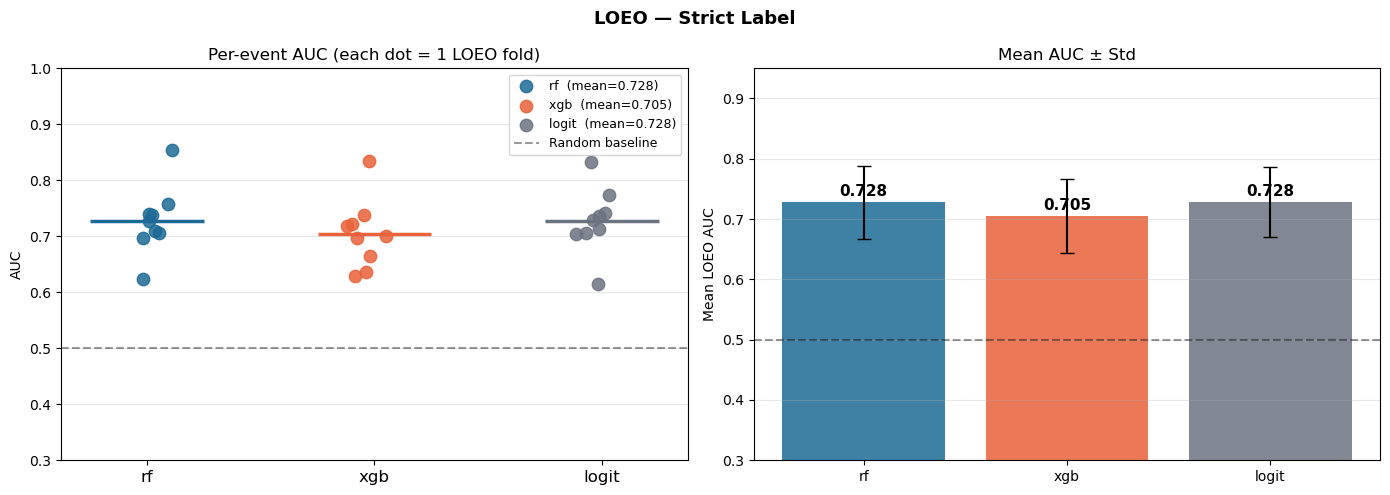

  Saved → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/loeo_LOEO_—_Strict_Label.png


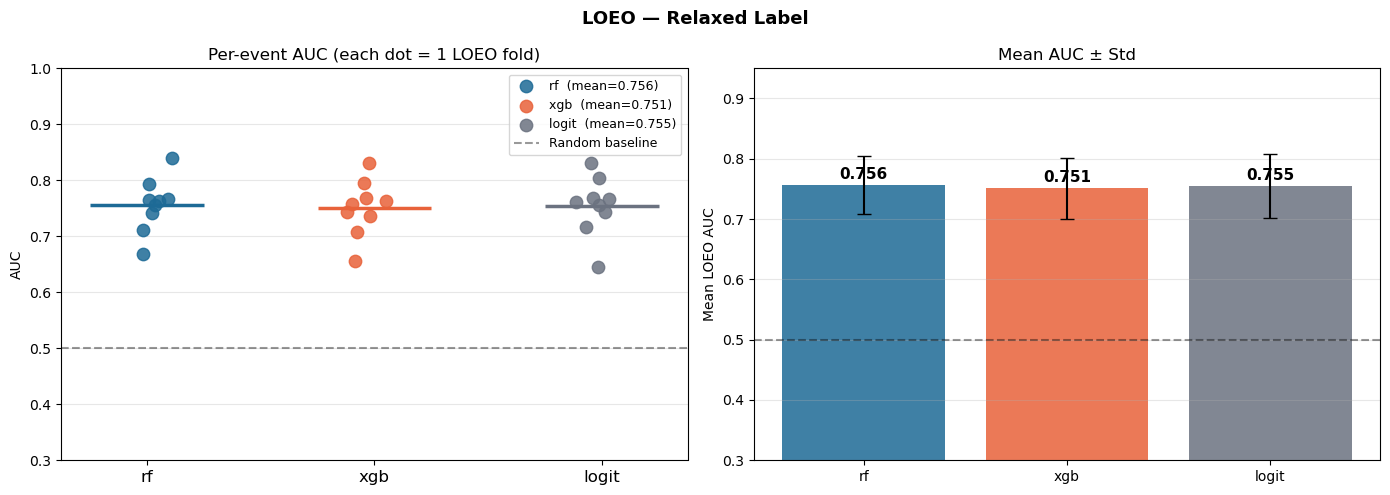

  Saved → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/loeo_LOEO_—_Relaxed_Label.png


In [173]:
def plot_loeo_summary(loeo_df, title="LOEO Results"):
    """Per-event AUC scatter + mean AUC bar chart for all three models."""
    colors = {"rf": "#1d6a96", "xgb": "#e8623a", "logit": "#6b7280"}
    model_names = ["rf", "xgb", "logit"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # Left: per-event AUC dots
    for i, m in enumerate(model_names):
        aucs = loeo_df[f"{m}_auc"].values
        jitter = np.random.RandomState(i).uniform(-0.12, 0.12, len(aucs))
        ax1.scatter([i + j for j in jitter], aucs,
                    color=colors[m], s=80, alpha=0.85, zorder=3,
                    label=f"{m}  (mean={aucs.mean():.3f})")
        ax1.hlines(aucs.mean(), i - 0.25, i + 0.25,
                   colors=colors[m], linewidths=2.5)
    ax1.axhline(0.5, ls="--", color="black", alpha=0.4, label="Random baseline")
    ax1.set_xticks(range(3)); ax1.set_xticklabels(model_names, fontsize=12)
    ax1.set_ylabel("AUC"); ax1.set_title("Per-event AUC (each dot = 1 LOEO fold)")
    ax1.legend(fontsize=9); ax1.set_ylim(0.3, 1.0); ax1.grid(axis="y", alpha=0.3)

    # Right: mean AUC bar
    mean_aucs = [loeo_df[f"{m}_auc"].mean() for m in model_names]
    std_aucs  = [loeo_df[f"{m}_auc"].std()  for m in model_names]
    bars = ax2.bar(model_names, mean_aucs, yerr=std_aucs,
                   color=[colors[m] for m in model_names],
                   alpha=0.85, capsize=5, error_kw={"linewidth": 1.5})
    ax2.axhline(0.5, ls="--", color="black", alpha=0.4)
    for bar, val in zip(bars, mean_aucs):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01, f"{val:.3f}",
                 ha="center", fontsize=11, fontweight="bold")
    ax2.set_ylabel("Mean LOEO AUC"); ax2.set_title("Mean AUC ± Std")
    ax2.set_ylim(0.3, 0.95); ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, f"loeo_{title.replace(' ','_')}.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show(); print(f"  Saved → {out}")


plot_loeo_summary(loeo_strict, "LOEO — Strict Label")
plot_loeo_summary(loeo_full,   "LOEO — Relaxed Label")


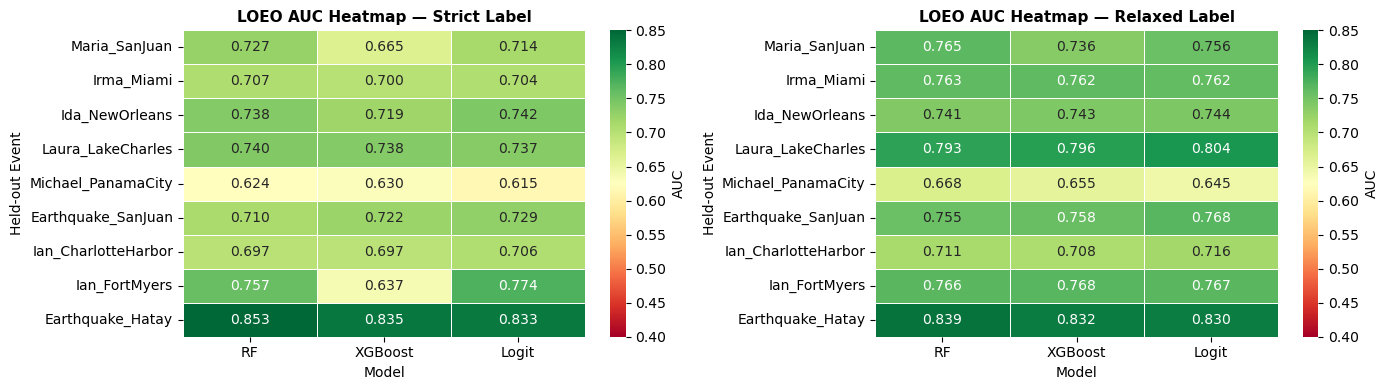

  Saved → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/loeo_heatmap_comparison.png


In [174]:
def plot_per_event_heatmap(loeo_strict, loeo_full):
    """Heatmap showing AUC by event and model for both label variants."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, loeo_df, title in [
        (axes[0], loeo_strict, "Strict Label"),
        (axes[1], loeo_full,   "Relaxed Label"),
    ]:
        heat_data = loeo_df.set_index("held_out")[
            ["rf_auc", "xgb_auc", "logit_auc"]
        ].rename(columns={"rf_auc": "RF", "xgb_auc": "XGBoost", "logit_auc": "Logit"})

        sns.heatmap(heat_data, ax=ax, annot=True, fmt=".3f",
                    cmap="RdYlGn", vmin=0.4, vmax=0.85,
                    linewidths=0.5, cbar_kws={"label": "AUC"})
        ax.set_title(f"LOEO AUC Heatmap — {title}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Model"); ax.set_ylabel("Held-out Event")
        ax.tick_params(axis="x", labelsize=10)

    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, "loeo_heatmap_comparison.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show(); print(f"  Saved → {out}")


plot_per_event_heatmap(loeo_strict, loeo_full)


## 6. Final Model — Train on All Events

In [175]:
def train_final_models(df, features, label_col="in_buffer_strict"):
    """
    Train RF and XGBoost on the full multi-event dataset.
    Saves models + feature importance CSV.
    """
    X = df[features].fillna(0).values
    y = df[label_col].values
    print(f"Training on {len(df):,} pixels, positives = {y.sum():,} ({100*y.mean():.1f}%)")

    # Random Forest
    rf_final = RandomForestClassifier(**RF_PARAMS)
    rf_final.fit(X, y)
    print("  RF trained ✓")

    # XGBoost (no early stopping when training on full data)
    xgb_params_final = {k: v for k, v in XGB_PARAMS.items()
                        if k not in ("early_stopping_rounds", "eval_metric")}
    xgb_final = xgb.XGBClassifier(**xgb_params_final)
    xgb_final.fit(X, y)
    print("  XGBoost trained ✓")

    # Feature importance table
    importance_df = pd.DataFrame({
        "feature":  features,
        "rf_imp":   rf_final.feature_importances_,
        "xgb_imp":  xgb_final.feature_importances_,
    })
    importance_df["avg_imp"] = (importance_df["rf_imp"] + importance_df["xgb_imp"]) / 2
    importance_df = importance_df.sort_values("avg_imp", ascending=False).reset_index(drop=True)

    # Save artefacts
    joblib.dump(rf_final,  os.path.join(OUTPUT_DIR, "rf_final.pkl"))
    joblib.dump(xgb_final, os.path.join(OUTPUT_DIR, "xgb_final.pkl"))
    importance_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance.csv"), index=False)
    print(f"  Models saved to {OUTPUT_DIR}")

    print("\nTop-10 features by average importance:")
    print(importance_df.head(10).to_string(index=False))
    return {"rf": rf_final, "xgb": xgb_final, "importance": importance_df}


final_models = train_final_models(df, features, label_col="in_buffer_strict")


Training on 15,539 pixels, positives = 3,289 (21.2%)
  RF trained ✓
  XGBoost trained ✓
  Models saved to /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2

Top-10 features by average importance:
             feature   rf_imp  xgb_imp  avg_imp
         log_pre_ntl 0.276172 0.132021 0.204097
         ntl_x_group 0.158754 0.059113 0.108933
      city_size_code 0.084393 0.109817 0.097105
         near_police 0.015425 0.177312 0.096368
   below_city_median 0.036224 0.136680 0.086452
        log_post_ntl 0.136573 0.034192 0.085382
        ntl_relative 0.112393 0.035681 0.074037
   log_city_pre_mean 0.056097 0.049506 0.052801
            log_dist 0.033695 0.065741 0.049718
below_median_x_group 0.036405 0.025296 0.030851


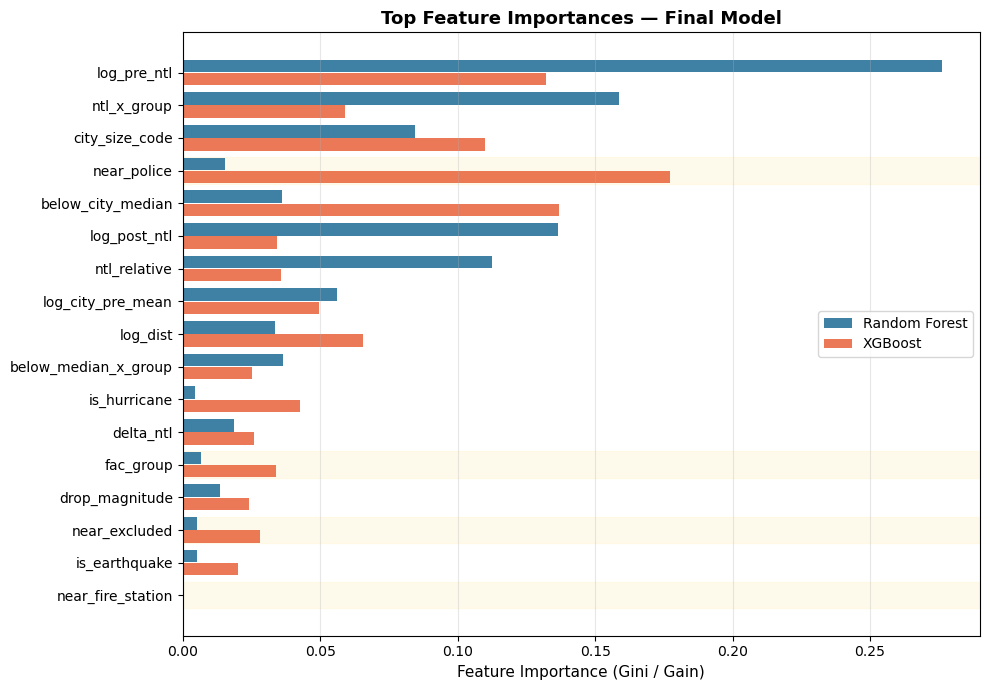

  Saved → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/feature_importance.png


In [176]:
def plot_feature_importance(importance_df):
    """Horizontal grouped bar chart: RF vs XGBoost importance for top features."""
    top_n  = min(20, len(importance_df))
    df_top = importance_df.head(top_n).copy()

    fig, ax = plt.subplots(figsize=(10, 7))
    y = np.arange(top_n)
    ax.barh(y - 0.2, df_top["rf_imp"],  height=0.38,
            label="Random Forest", color="#1d6a96", alpha=0.85)
    ax.barh(y + 0.2, df_top["xgb_imp"], height=0.38,
            label="XGBoost",       color="#e8623a", alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(df_top["feature"], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Feature Importance (Gini / Gain)", fontsize=11)
    ax.set_title("Top Feature Importances — Final Model", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10); ax.grid(axis="x", alpha=0.3)

    # Highlight facility-type features in a different colour band
    fac_features = [f for f in df_top["feature"]
                    if f.startswith("near_") or f == "fac_group"]
    for i, feat in enumerate(df_top["feature"]):
        if feat in fac_features:
            ax.axhspan(i - 0.4, i + 0.4, color="#fef3c7", alpha=0.35, zorder=0)

    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, "feature_importance.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show(); print(f"  Saved → {out}")


plot_feature_importance(final_models["importance"])


## 7. Per-Event Probability Maps
Generate GeoTIFF: `P(backup_power_present)` for each event × pixel.

In [177]:
def generate_probability_maps(df, features, models, events, data_dir):
    """
    For each event output THREE files:
      1. PNG  — static publication figure, viewable in any image viewer
      2. HTML — interactive Leaflet map (hover tooltips, layer toggle, facility markers)
      3. GeoTIFF — for GIS use
    """
    try:
        import folium
        from folium.plugins import HeatMap
        HAS_FOLIUM = True
    except ImportError:
        print("  [INFO] folium not installed — skipping HTML output")
        print("         Run: pip install folium --break-system-packages")
        HAS_FOLIUM = False

    print("Generating probability maps ...")

    for event_id, cfg in events.items():
        event_df = df[df["event_id"] == event_id].copy()
        if event_df.empty:
            continue

        pre_tifs = sorted(glob.glob(os.path.join(data_dir, cfg["pre"], "*.tif")))
        if not pre_tifs:
            print(f"  [SKIP] No pre TIFs for {event_id}"); continue

        with rasterio.open(pre_tifs[0]) as src:
            profile   = src.profile.copy()
            height    = src.height
            width     = src.width
            transform = src.transform
            tif_crs   = src.crs

        X_ev     = event_df[features].fillna(0).values
        rf_prob  = models["rf"].predict_proba(X_ev)[:, 1]
        xgb_prob = models["xgb"].predict_proba(X_ev)[:, 1]
        ens_prob = rf_prob * 0.7 + xgb_prob * 0.3  # weighted: RF more discriminative

        rows_px = event_df["row"].values
        cols_px = event_df["col"].values

        def to_grid(probs):
            arr = np.full((height, width), np.nan, dtype=np.float32)
            arr[rows_px, cols_px] = probs
            return arr

        grid_rf  = to_grid(rf_prob)
        grid_xgb = to_grid(xgb_prob)
        grid_ens = to_grid(ens_prob)

        # Load POI cache
        poi_cache = os.path.join(OUTPUT_DIR, "poi_cache", f"{event_id}_poi.csv")
        poi_df = pd.read_csv(poi_cache) if os.path.exists(poi_cache) else pd.DataFrame()

        # Compute pixel lon/lat for HTML map
        xs, ys = rasterio.transform.xy(transform, rows_px, cols_px, offset="center")
        # xs/ys are in TIF CRS — convert to WGS84 if needed
        from pyproj import Transformer
        if str(tif_crs).upper() != "EPSG:4326":
            transformer = Transformer.from_crs(tif_crs, "EPSG:4326", always_xy=True)
            lons, lats = transformer.transform(xs, ys)
        else:
            lons, lats = np.array(xs), np.array(ys)

        # ── 1. PNG: 3-panel static figure ────────────────────────────────────
        cmap = plt.cm.RdYlGn
        fac_style = {
            "hospital":     dict(color="#ff4444", marker="+",  s=60, label="Hospital"),
            "aerodrome":    dict(color="#ff8800", marker="^",  s=60, label="Airport"),
            "power_plant":  dict(color="#ffdd00", marker="D",  s=40, label="Power Plant"),
            "fire_station": dict(color="#44aaff", marker="s",  s=40, label="Fire Station"),
            "police":       dict(color="#aa44ff", marker="o",  s=40, label="Police"),
            "government":   dict(color="#ffffff", marker="x",  s=40, label="Government"),
            "substation":   dict(color="#aaffaa", marker="v",  s=30, label="Substation"),
            "water_works":  dict(color="#44ffff", marker="*",  s=40, label="Water Works"),
        }

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.patch.set_facecolor("#1a1a2e")

        for ax, (title, arr) in zip(axes, [
            ("Random Forest", grid_rf),
            ("XGBoost",       grid_xgb),
            ("Ensemble",      grid_ens),
        ]):
            ax.set_facecolor("#0d0d1a")
            # Grey NTL context layer
            pre_grid = np.full((height, width), np.nan, dtype=np.float32)
            pre_grid[rows_px, cols_px] = event_df["pre_mean_ntl"].values
            ax.imshow(np.log1p(pre_grid), cmap="gray", alpha=0.35,
                      vmin=0, interpolation="nearest")
            # Probability layer
            im = ax.imshow(arr, cmap=cmap, vmin=0, vmax=1,
                           alpha=0.85, interpolation="nearest")
            # Facility markers
            if not poi_df.empty:
                plotted = set()
                for _, fac in poi_df.iterrows():
                    ft = fac["facility_type"]
                    st = fac_style.get(ft, dict(color="white", marker="o", s=30, label=ft))
                    try:
                        col_f, row_f = ~transform * (fac["lon"], fac["lat"])
                        if 0 <= row_f < height and 0 <= col_f < width:
                            ax.scatter(col_f, row_f,
                                       c=st["color"], marker=st["marker"], s=st["s"],
                                       edgecolors="black", linewidths=0.6, zorder=5,
                                       label=st["label"] if ft not in plotted else "")
                            plotted.add(ft)
                    except Exception:
                        pass
            ax.set_title(title, color="white", fontsize=13, fontweight="bold", pad=8)
            ax.axis("off")
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("P(backup power)", color="white", fontsize=9)
            cbar.ax.yaxis.set_tick_params(color="white")
            plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

        # Facility legend on last panel
        if not poi_df.empty:
            handles, seen = [], set()
            for ft in poi_df["facility_type"].unique():
                if ft not in seen:
                    st = fac_style.get(ft, dict(color="white", marker="o", s=30, label=ft))
                    handles.append(plt.scatter([], [], c=st["color"], marker=st["marker"],
                                               s=st["s"], label=st["label"],
                                               edgecolors="black", linewidths=0.6))
                    seen.add(ft)
            axes[-1].legend(handles=handles, loc="lower right", fontsize=8,
                            facecolor="#1a1a2e", labelcolor="white",
                            framealpha=0.8, title="Facility Type", title_fontsize=8)

        fig.suptitle(
            f"{cfg['city']} — {cfg['disaster_type'].title()}  |  Backup Power Probability",
            color="white", fontsize=14, fontweight="bold", y=1.01
        )
        plt.tight_layout()
        out_png = os.path.join(OUTPUT_DIR, f"{event_id}_prob_map.png")
        plt.savefig(out_png, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        plt.close()
        print(f"  ✓ PNG  : {out_png}")

        # ── 2. GeoTIFF ────────────────────────────────────────────────────────
        profile.update(count=3, dtype="float32", nodata=0.0, compress="lzw")
        out_tif = os.path.join(OUTPUT_DIR, f"{event_id}_prob_map.tif")
        with rasterio.open(out_tif, "w", **profile) as dst:
            dst.write(grid_rf,  1)
            dst.write(grid_xgb, 2)
            dst.write(grid_ens, 3)
        print(f"  ✓ TIF  : {out_tif}")

        # ── 3. Interactive HTML (Folium) ──────────────────────────────────────
        if not HAS_FOLIUM:
            continue

        center_lat = float(np.mean(lats))
        center_lon = float(np.mean(lons))
        m = folium.Map(location=[center_lat, center_lon],
                       zoom_start=12, tiles=None)

        # Base tile layers
        folium.TileLayer("CartoDB dark_matter", name="Dark (default)").add_to(m)
        folium.TileLayer("OpenStreetMap",        name="OpenStreetMap").add_to(m)
        folium.TileLayer("CartoDB positron",     name="Light").add_to(m)

        # Ensemble heatmap layer
        heat_data = [
            [float(lat), float(lon), float(p)]
            for lat, lon, p in zip(lats, lons, ens_prob)
            if not np.isnan(p) and p > 0.1   # only show meaningful probabilities
        ]
        HeatMap(heat_data, name="Ensemble Probability (heatmap)",
                min_opacity=0.3, max_zoom=16,
                radius=15, blur=12,
                gradient={0.0: "red", 0.4: "orange",
                           0.6: "yellow", 1.0: "green"}).add_to(m)

        # Per-pixel circle markers with tooltip (ensemble, sampled for performance)
        pixel_fg = folium.FeatureGroup(name="Pixel Probabilities (hover)", show=False)
        step = max(1, len(lats) // 2000)   # cap at ~2000 markers
        for lat, lon, p_rf, p_xgb, p_ens, delta, pre in zip(
            lats[::step], lons[::step],
            rf_prob[::step], xgb_prob[::step], ens_prob[::step],
            event_df["delta_ntl"].values[::step],
            event_df["pre_mean_ntl"].values[::step],
        ):
            color = (f"#{int((1-p_ens)*255):02x}"
                     f"{int(p_ens*255):02x}00")   # red→green by probability
            folium.CircleMarker(
                location=[float(lat), float(lon)],
                radius=4,
                color=color, fill=True, fill_color=color, fill_opacity=0.7,
                tooltip=folium.Tooltip(
                    f"<b>P(backup) RF:</b> {p_rf:.3f}<br>"
                    f"<b>P(backup) XGB:</b> {p_xgb:.3f}<br>"
                    f"<b>P(backup) Ens:</b> {p_ens:.3f}<br>"
                    f"<b>NTL change:</b> {delta:+.1%}<br>"
                    f"<b>Pre-NTL:</b> {pre:.2f} nW/cm²/sr"
                )
            ).add_to(pixel_fg)
        pixel_fg.add_to(m)

        # Facility markers
        if not poi_df.empty:
            html_fac_colors = {
                "hospital": "red", "aerodrome": "orange", "power_plant": "beige",
                "fire_station": "blue", "police": "purple",
                "government": "white", "substation": "green", "water_works": "cadetblue",
            }
            html_fac_icons = {
                "hospital": "plus-sign", "aerodrome": "plane", "power_plant": "flash",
                "fire_station": "fire", "police": "star",
                "government": "home", "substation": "transfer", "water_works": "tint",
            }
            for ft in poi_df["facility_type"].unique():
                fg = folium.FeatureGroup(name=f"Facility: {ft}")
                subset = poi_df[poi_df["facility_type"] == ft]
                for _, fac in subset.iterrows():
                    folium.Marker(
                        location=[fac["lat"], fac["lon"]],
                        popup=folium.Popup(
                            f"<b>{ft.replace('_',' ').title()}</b><br>"
                            f"Lat: {fac['lat']:.4f}<br>Lon: {fac['lon']:.4f}",
                            max_width=200
                        ),
                        icon=folium.Icon(
                            color=html_fac_colors.get(ft, "gray"),
                            icon=html_fac_icons.get(ft, "info-sign"),
                            prefix="glyphicon"
                        )
                    ).add_to(fg)
                fg.add_to(m)

        folium.LayerControl(collapsed=False).add_to(m)

        # Title box
        title_html = f"""
        <div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
                    z-index:1000; background:rgba(0,0,0,0.75); color:white;
                    padding:8px 16px; border-radius:6px; font-size:14px;
                    font-family:Arial; font-weight:bold; pointer-events:none;">
            {cfg["city"]} — {cfg["disaster_type"].title()} | Backup Power Probability
        </div>"""
        m.get_root().html.add_child(folium.Element(title_html))

        out_html = os.path.join(OUTPUT_DIR, f"{event_id}_prob_map.html")
        m.save(out_html)
        print(f"  ✓ HTML : {out_html}")

    print("\nAll outputs saved.")


print("generate_probability_maps() defined ✓")
print("Outputs per event: PNG (static) + GeoTIFF (GIS) + HTML (interactive)")


generate_probability_maps() defined ✓
Outputs per event: PNG (static) + GeoTIFF (GIS) + HTML (interactive)


In [178]:
# ── Run: generate PNG + HTML + GeoTIFF for all six events ────────────────────
generate_probability_maps(df, features, final_models, EVENTS, DATA_DIR)


Generating probability maps ...
  ✓ PNG  : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Maria_SanJuan_prob_map.png
  ✓ TIF  : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Maria_SanJuan_prob_map.tif
  ✓ HTML : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Maria_SanJuan_prob_map.html
  ✓ PNG  : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Irma_Miami_prob_map.png
  ✓ TIF  : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Irma_Miami_prob_map.tif
  ✓ HTML : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Irma_Miami_prob_map.html
  ✓ PNG  : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Ida_NewOrleans_prob_map.png
  ✓ TIF  : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Ida_NewOrleans_prob_map.tif
  ✓ HTML : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/I

## 8. OOF Probability Distribution by Facility Group
Diagnostic: do high-signal facility buffers get higher predicted probabilities?

In [179]:
# Attach OOF predictions from strict-label LOEO
df["oof_rf"]    = oof_strict["rf"].values
df["oof_xgb"]   = oof_strict["xgb"].values
df["oof_logit"] = oof_strict["logit"].values

# Summarise by facility group × buffer status
summary = df.groupby(["nearest_fac_group", "in_buffer_strict"])[
    ["oof_rf", "oof_xgb"]
].mean().round(3)

print("OOF predicted probability by facility group and buffer status:")
print(summary)
print()
print("Interpretation: Group 1 (hospital/airport/power_plant) in-buffer pixels")
print("should have the highest predicted probability — confirms facility-type control works")


OOF predicted probability by facility group and buffer status:
                                    oof_rf  oof_xgb
nearest_fac_group in_buffer_strict                 
1                 0                  0.326    0.505
                  1                  0.406    0.548
2                 0                  0.470    0.525
                  1                  0.573    0.623
3                 0                  0.392    0.438
                  1                  0.611    0.641

Interpretation: Group 1 (hospital/airport/power_plant) in-buffer pixels
should have the highest predicted probability — confirms facility-type control works


Pixel counts per plot group:
plot_group
Outside buffer                               10371
Group 1\n(hospital/airport/\npower_plant)     2366
Group 3\n(excluded types only)                1879
Group 2\n(fire_station/\npolice)               923
Name: count, dtype: int64


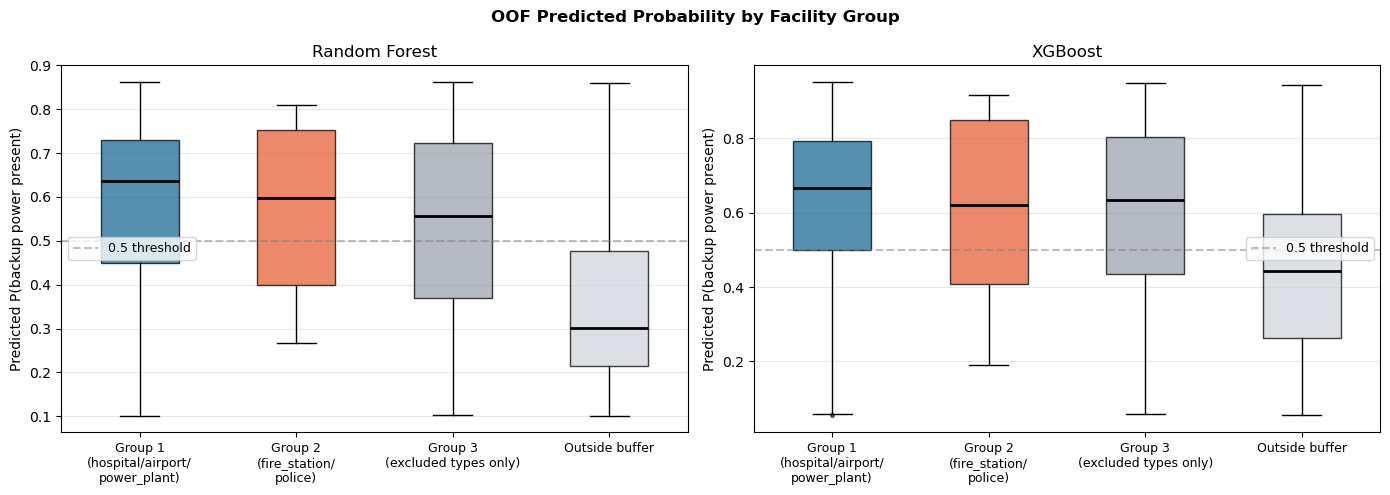

Saved → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/prob_by_facility_group.png


In [180]:
# ── OOF probability distribution by facility group ───────────────────────────
# Grouping logic: based on which strict-buffer type the pixel BELONGS to,
# not the nearest facility (those can differ due to spatial overlap).
#
# Strategy:
#   Group 1 pixels: in_buffer_strict=1 AND nearest_fac_type in HIGH_SIGNAL_TYPES
#   Group 2 pixels: in_buffer_strict=1 AND nearest_fac_type in MEDIUM_SIGNAL_TYPES
#   Group 3 pixels: in_buffer=1 but in_buffer_strict=0 (in excluded-type buffers only)
#   Outside:        in_buffer=0 (negative class, shown for reference)

def assign_plot_group(row):
    if row["in_buffer_strict"] == 1:
        if row["nearest_fac_type"] in HIGH_SIGNAL_TYPES:
            return "Group 1\n(hospital/airport/\npower_plant)"
        elif row["nearest_fac_type"] in MEDIUM_SIGNAL_TYPES:
            return "Group 2\n(fire_station/\npolice)"
        else:
            # in strict buffer but nearest is excluded type — assign by group ordinal
            return "Group 2\n(fire_station/\npolice)" if row["nearest_fac_group"] <= 2                    else "Group 1\n(hospital/airport/\npower_plant)"
    elif row["in_buffer"] == 1:
        return "Group 3\n(excluded types only)"
    else:
        return "Outside buffer"

df["plot_group"] = df.apply(assign_plot_group, axis=1)

GROUP_ORDER = [
    "Group 1\n(hospital/airport/\npower_plant)",
    "Group 2\n(fire_station/\npolice)",
    "Group 3\n(excluded types only)",
    "Outside buffer",
]
GROUP_COLORS = ["#1d6a96", "#e8623a", "#9ca3af", "#d1d5db"]

print("Pixel counts per plot group:")
print(df["plot_group"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("OOF Predicted Probability by Facility Group",
             fontsize=12, fontweight="bold")

for ax, col, label in [
    (axes[0], "oof_rf",  "Random Forest"),
    (axes[1], "oof_xgb", "XGBoost"),
]:
    data_per_group = []
    labels_present = []
    colors_present = []

    for grp, color in zip(GROUP_ORDER, GROUP_COLORS):
        vals = df[df["plot_group"] == grp][col].dropna().values
        if len(vals) > 0:
            data_per_group.append(vals)
            labels_present.append(grp)
            colors_present.append(color)

    bps = ax.boxplot(data_per_group,
                     positions=range(len(data_per_group)),
                     widths=0.5, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2),
                     flierprops=dict(marker="o", markersize=2, alpha=0.3))

    for patch, color in zip(bps["boxes"], colors_present):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticks(range(len(labels_present)))
    ax.set_xticklabels(labels_present, fontsize=9)
    ax.set_ylabel("Predicted P(backup power present)")
    ax.set_title(f"{label}")
    ax.axhline(0.5, ls="--", color="gray", alpha=0.5, label="0.5 threshold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "prob_by_facility_group.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


## 9. Output Summary

## 10. Extended Evaluation: Grouped AUC + Precision/Recall

In [181]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report)

# ── A. Precision / Recall / F1 at threshold = 0.5 ────────────────────────────
print("=" * 65)
print("A. Classification Metrics @ threshold = 0.5  (Strict label)")
print("=" * 65)

df["oof_ens"] = df["oof_rf"] * 0.7 + df["oof_xgb"] * 0.3

rows_pr = []
for model_name, oof_col in [("RF", "oof_rf"), ("XGBoost", "oof_xgb"),
                              ("Ensemble (0.7RF+0.3XGB)", "oof_ens")]:
    valid = df[oof_col].notna() & df["in_buffer_strict"].notna()
    y_true = df.loc[valid, "in_buffer_strict"].values
    y_prob = df.loc[valid, oof_col].values
    y_pred = (y_prob >= 0.5).astype(int)

    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc= roc_auc_score(y_true, y_prob)
    rows_pr.append({"Model": model_name, "AUC": auc,
                    "Precision": p, "Recall": r, "F1": f1})
    print(f"  {model_name}")
    print(f"    AUC={auc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}")

pr_df = pd.DataFrame(rows_pr)
pr_df.to_csv(os.path.join(OUTPUT_DIR, "precision_recall_results.csv"), index=False)
print(f"\nSaved → precision_recall_results.csv")

# ── B. Grouped AUC by city size ───────────────────────────────────────────────
print("\n" + "=" * 65)
print("B. LOEO AUC by City Size  (RF, Strict label)")
print("=" * 65)

loeo_strict = pd.read_csv(os.path.join(OUTPUT_DIR, "loeo_strict.csv"))

# Map event → city size
event_size_map = {cfg["city"]: cfg["city_size"] for cfg in EVENTS.values()}
event_to_size  = {k: v["city_size"] for k, v in EVENTS.items()}
loeo_strict["city_size"] = loeo_strict["held_out"].map(event_to_size)

size_summary = loeo_strict.groupby("city_size")["rf_auc"].agg(
    n_events="count", mean_auc="mean", std_auc="std", min_auc="min", max_auc="max"
).round(3)
print(size_summary.to_string())
size_summary.to_csv(os.path.join(OUTPUT_DIR, "grouped_auc_by_city_size.csv"))

# ── C. Grouped AUC by disaster type ───────────────────────────────────────────
print("\n" + "=" * 65)
print("C. LOEO AUC by Disaster Type  (RF, Strict label)")
print("=" * 65)

event_to_disaster = {k: v["disaster_type"] for k, v in EVENTS.items()}
loeo_strict["disaster_type"] = loeo_strict["held_out"].map(event_to_disaster)

disaster_summary = loeo_strict.groupby("disaster_type")["rf_auc"].agg(
    n_events="count", mean_auc="mean", std_auc="std", min_auc="min", max_auc="max"
).round(3)
print(disaster_summary.to_string())
disaster_summary.to_csv(os.path.join(OUTPUT_DIR, "grouped_auc_by_disaster.csv"))


A. Classification Metrics @ threshold = 0.5  (Strict label)
  RF
    AUC=0.760  Precision=0.390  Recall=0.667  F1=0.492
  XGBoost
    AUC=0.706  Precision=0.316  Recall=0.720  F1=0.439
  Ensemble (0.7RF+0.3XGB)
    AUC=0.747  Precision=0.369  Recall=0.682  F1=0.479

Saved → precision_recall_results.csv

B. LOEO AUC by City Size  (RF, Strict label)
           n_events  mean_auc  std_auc  min_auc  max_auc
city_size                                               
large             4     0.720    0.015    0.707    0.738
medium            2     0.805    0.068    0.757    0.853
small             3     0.687    0.058    0.624    0.740

C. LOEO AUC by Disaster Type  (RF, Strict label)
               n_events  mean_auc  std_auc  min_auc  max_auc
disaster_type                                               
earthquake            2     0.782    0.101    0.710    0.853
hurricane             7     0.713    0.044    0.624    0.757


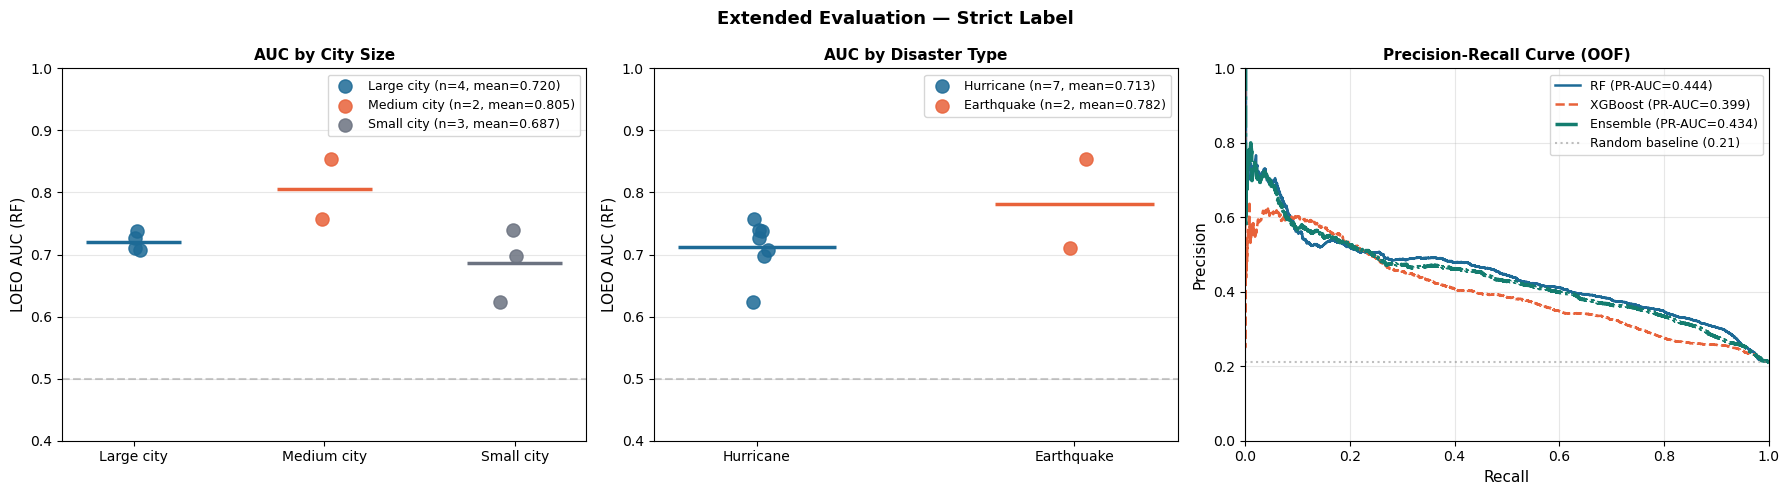

Saved → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/extended_evaluation.png


In [182]:
# ── Visualise: grouped AUC + PR curve ────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Extended Evaluation — Strict Label", fontsize=13, fontweight="bold")

# ── Left: grouped AUC by city size ────────────────────────────────────────────
ax = axes[0]
size_order  = ["large", "medium", "small"]
size_colors = {"large": "#1d6a96", "medium": "#e8623a", "small": "#6b7280"}
size_labels = {"large": "Large city", "medium": "Medium city", "small": "Small city"}

for i, size in enumerate(size_order):
    subset = loeo_strict[loeo_strict["city_size"] == size]
    if subset.empty: continue
    aucs   = subset["rf_auc"].values
    jitter = np.random.RandomState(i).uniform(-0.08, 0.08, len(aucs))
    ax.scatter([i + j for j in jitter], aucs,
               color=size_colors[size], s=90, alpha=0.85, zorder=3,
               label=f"{size_labels[size]} (n={len(aucs)}, mean={aucs.mean():.3f})")
    ax.hlines(aucs.mean(), i - 0.25, i + 0.25,
              colors=size_colors[size], linewidths=2.5)

ax.axhline(0.5, ls="--", color="gray", alpha=0.4)
ax.set_xticks(range(len(size_order)))
ax.set_xticklabels([size_labels[s] for s in size_order], fontsize=10)
ax.set_ylabel("LOEO AUC (RF)", fontsize=11)
ax.set_title("AUC by City Size", fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.set_ylim(0.4, 1.0); ax.grid(axis="y", alpha=0.3)

# ── Middle: grouped AUC by disaster type ──────────────────────────────────────
ax = axes[1]
dis_order  = ["hurricane", "earthquake"]
dis_colors = {"hurricane": "#1d6a96", "earthquake": "#e8623a"}

for i, dis in enumerate(dis_order):
    subset = loeo_strict[loeo_strict["disaster_type"] == dis]
    if subset.empty: continue
    aucs   = subset["rf_auc"].values
    jitter = np.random.RandomState(i).uniform(-0.08, 0.08, len(aucs))
    ax.scatter([i + j for j in jitter], aucs,
               color=dis_colors[dis], s=90, alpha=0.85, zorder=3,
               label=f"{dis.title()} (n={len(aucs)}, mean={aucs.mean():.3f})")
    ax.hlines(aucs.mean(), i - 0.25, i + 0.25,
              colors=dis_colors[dis], linewidths=2.5)

ax.axhline(0.5, ls="--", color="gray", alpha=0.4)
ax.set_xticks(range(len(dis_order)))
ax.set_xticklabels([d.title() for d in dis_order], fontsize=10)
ax.set_ylabel("LOEO AUC (RF)", fontsize=11)
ax.set_title("AUC by Disaster Type", fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.set_ylim(0.4, 1.0); ax.grid(axis="y", alpha=0.3)

# ── Right: PR curve (ensemble OOF) ────────────────────────────────────────────
ax = axes[2]
model_styles = {
    "RF":      dict(color="#1d6a96", ls="-"),
    "XGBoost": dict(color="#e8623a", ls="--"),
    "Ensemble":dict(color="#147D6F", ls="-.", lw=2.5),
}
for model_name, oof_col in [("RF", "oof_rf"), ("XGBoost", "oof_xgb"),
                              ("Ensemble", "oof_ens")]:
    valid  = df[oof_col].notna() & df["in_buffer_strict"].notna()
    y_true = df.loc[valid, "in_buffer_strict"].values
    y_prob = df.loc[valid, oof_col].values
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    st = model_styles[model_name]
    ax.plot(rec, prec, color=st["color"], ls=st["ls"],
            lw=st.get("lw", 1.8),
            label=f"{model_name} (PR-AUC={ap:.3f})")

# Baseline: random classifier precision = positive rate
baseline = df["in_buffer_strict"].mean()
ax.axhline(baseline, ls=":", color="gray", alpha=0.5,
           label=f"Random baseline ({baseline:.2f})")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall Curve (OOF)", fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "extended_evaluation.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


## 11. Model B — Post-Disaster Behavior Only (No Pre-NTL)

**Motivation**: The original model's probability map correlates strongly with
pre-disaster brightness, suggesting the model may be learning facility *location*
rather than backup generator *activation behavior*.

**Experiment**: Remove all pre-disaster brightness features and force the model
to rely solely on post-disaster NTL behavior. If AUC stays high, the behavioral
signal is real. If AUC drops significantly, the original signal was mainly spatial.

**Features removed**: `log_pre_ntl`, `ntl_relative`, `log_city_pre_mean`,
`below_city_median`, `below_median_x_group`, `ntl_x_group`  
**Features kept**: `delta_ntl`, `drop_magnitude`, `log_post_ntl`,
`log_dist`, facility type controls, city/disaster structure


In [183]:
def engineer_features_post_only(df):
    """
    Model B: post-disaster behavior features only.
    All pre-disaster brightness features removed to test whether
    the generator signal is truly behavioral (post-disaster) or
    merely spatial (correlated with pre-disaster brightness).
    """
    df = df.copy()

    # ── Post-disaster NTL behavior (the core signal we want to test) ──────────
    df["drop_magnitude"] = -df["delta_ntl"].clip(upper=0)
    df["log_post_ntl"]   = np.log1p(df["post_mean_ntl"])

    # Recovery relative to city post-mean (city-level normalization, post only)
    city_post_mean = df.groupby("event_id")["post_mean_ntl"].transform("mean")
    df["post_ntl_relative"] = df["post_mean_ntl"] / (city_post_mean + 1e-6)

    # ── Spatial proximity ─────────────────────────────────────────────────────
    df["log_dist"] = np.log1p(df["dist_to_facility"])

    # ── Facility type controls ────────────────────────────────────────────────
    df["near_fire_station"] = (df["nearest_fac_type"] == "fire_station").astype(np.uint8)
    df["near_police"]       = (df["nearest_fac_type"] == "police").astype(np.uint8)
    df["near_excluded"]     = df["nearest_fac_type"].isin(EXCLUDED_TYPES).astype(np.uint8)
    df["fac_group"]         = df["nearest_fac_group"].astype(np.float32)

    # ── City / disaster structure ─────────────────────────────────────────────
    df["city_size_code"] = df["city_size"].map(
        {"large": 0, "medium": 1, "small": 2}).fillna(1)
    df["is_hurricane"]   = (df["disaster_type"] == "hurricane").astype(np.uint8)
    df["is_earthquake"]  = (df["disaster_type"] == "earthquake").astype(np.uint8)

    # ── Interaction: post behavior × facility group ───────────────────────────
    df["post_ntl_x_group"] = df["log_post_ntl"] * df["fac_group"]

    features_b = [
        # Post-disaster behavior only (NO pre-NTL)
        "drop_magnitude", "delta_ntl",
        "log_post_ntl", "post_ntl_relative",
        # Spatial proximity
        "log_dist",
        # Facility type controls
        "near_fire_station", "near_police",
        "near_excluded", "fac_group",
        # City / disaster structure
        "city_size_code", "is_hurricane", "is_earthquake",
        # Interaction
        "post_ntl_x_group",
    ]

    print(f"Model B features ({len(features_b)}): {features_b}")
    return df, features_b


df_b, features_b = engineer_features_post_only(df)
print("Model B feature matrix ready ✓")


Model B features (13): ['drop_magnitude', 'delta_ntl', 'log_post_ntl', 'post_ntl_relative', 'log_dist', 'near_fire_station', 'near_police', 'near_excluded', 'fac_group', 'city_size_code', 'is_hurricane', 'is_earthquake', 'post_ntl_x_group']
Model B feature matrix ready ✓


In [184]:
# ── Run LOEO for Model B ──────────────────────────────────────────────────────
print("=" * 65)
print("MODEL B — Post-Disaster Behavior Only (no pre-NTL features)")
print("=" * 65)
loeo_b, oof_b = run_loeo(df_b, features_b, label_col="in_buffer_strict")
loeo_b.to_csv(os.path.join(OUTPUT_DIR, "loeo_modelB.csv"), index=False)


MODEL B — Post-Disaster Behavior Only (no pre-NTL features)
LOEO — label = 'in_buffer_strict'
Events: ['Maria_SanJuan', 'Irma_Miami', 'Ida_NewOrleans', 'Laura_LakeCharles', 'Michael_PanamaCity', 'Earthquake_SanJuan', 'Ian_CharlotteHarbor', 'Ian_FortMyers', 'Earthquake_Hatay']
----------------------------------------------------------------------

  Hold-out: Maria_SanJuan
  train: n=14,146  pos=2821 (19.9%)
  test:  n=1,393  pos=468 (33.6%)
    RF     AUC=0.685  PR-AUC=0.532
    XGBoost AUC=0.665  PR-AUC=0.513
    Logit   AUC=0.702  PR-AUC=0.549

  Hold-out: Irma_Miami
  train: n=13,279  pos=2498 (18.8%)
  test:  n=2,260  pos=791 (35.0%)
    RF     AUC=0.706  PR-AUC=0.549
    XGBoost AUC=0.700  PR-AUC=0.554
    Logit   AUC=0.703  PR-AUC=0.544

  Hold-out: Ida_NewOrleans
  train: n=13,152  pos=2560 (19.5%)
  test:  n=2,387  pos=729 (30.5%)
    RF     AUC=0.731  PR-AUC=0.493
    XGBoost AUC=0.704  PR-AUC=0.447
    Logit   AUC=0.741  PR-AUC=0.554

  Hold-out: Laura_LakeCharles
  train: n=

In [185]:
# ── Model A vs Model B: Direct Comparison ────────────────────────────────────
print("\n" + "=" * 65)
print("Model A (with pre-NTL) vs Model B (post-only) — RF, Strict Label")
print("=" * 65)

loeo_a = pd.read_csv(os.path.join(OUTPUT_DIR, "loeo_strict.csv"))

print(f"\n{'Event':25s}  {'Model A AUC':>12s}  {'Model B AUC':>12s}  {'Δ(A−B)':>10s}")
print("-" * 65)
for _, row_a in loeo_a.iterrows():
    event = row_a["held_out"]
    row_b = loeo_b[loeo_b["held_out"] == event]
    if row_b.empty: continue
    a_auc = row_a["rf_auc"]
    b_auc = row_b["rf_auc"].values[0]
    delta = a_auc - b_auc
    flag  = " ← pre-NTL helps" if delta > 0.03 else             " ← behavioral signal real" if delta < -0.01 else ""
    print(f"{event:25s}  {a_auc:12.3f}  {b_auc:12.3f}  {delta:+10.3f}{flag}")

mean_a = loeo_a["rf_auc"].mean()
mean_b = loeo_b["rf_auc"].mean()
print("-" * 65)
print(f"{'MEAN':25s}  {mean_a:12.3f}  {mean_b:12.3f}  {mean_a-mean_b:+10.3f}")
print()
if mean_a - mean_b > 0.05:
    print("Interpretation: Pre-NTL contributes substantially (+>0.05).")
    print("  Model is partly learning facility location, not just behavior.")
    print("  Recommend reporting both models; use Model B for behavioral claims.")
elif mean_a - mean_b > 0.02:
    print("Interpretation: Pre-NTL helps moderately (+0.02–0.05).")
    print("  Both spatial position AND post-disaster behavior carry signal.")
    print("  Original model is valid; acknowledge spatial component in paper.")
else:
    print("Interpretation: Pre-NTL contributes minimally (<0.02).")
    print("  Post-disaster behavioral signal is the primary driver.")
    print("  Original model claims are well-supported.")



Model A (with pre-NTL) vs Model B (post-only) — RF, Strict Label

Event                       Model A AUC   Model B AUC      Δ(A−B)
-----------------------------------------------------------------
Maria_SanJuan                     0.727         0.685      +0.042 ← pre-NTL helps
Irma_Miami                        0.707         0.706      +0.001
Ida_NewOrleans                    0.738         0.731      +0.008
Laura_LakeCharles                 0.740         0.741      -0.001
Michael_PanamaCity                0.624         0.617      +0.008
Earthquake_SanJuan                0.710         0.708      +0.002
Ian_CharlotteHarbor               0.697         0.702      -0.004
Ian_FortMyers                     0.757         0.786      -0.029 ← behavioral signal real
Earthquake_Hatay                  0.853         0.839      +0.014
-----------------------------------------------------------------
MEAN                              0.728         0.724      +0.004

Interpretation: Pre-NTL contribut

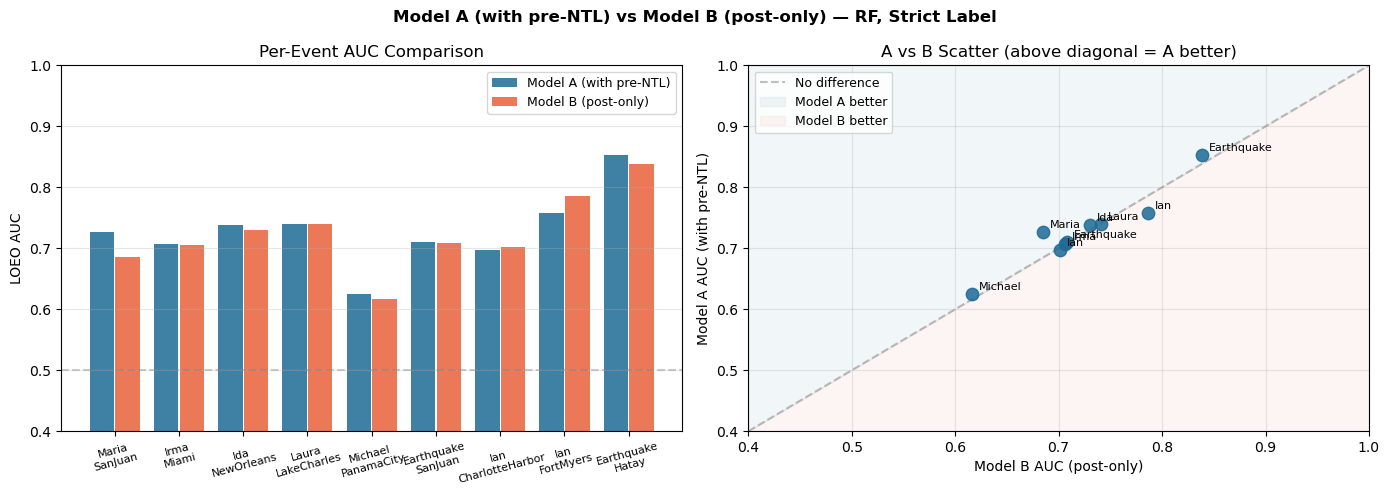

Saved → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/modelA_vs_modelB.png


In [186]:
# ── Visualise: Model A vs B per-event AUC comparison ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model A (with pre-NTL) vs Model B (post-only) — RF, Strict Label",
             fontsize=12, fontweight="bold")

events_list = loeo_a["held_out"].tolist()
x = np.arange(len(events_list))

# ── Left: side-by-side bar per event ─────────────────────────────────────────
ax = axes[0]
a_aucs = [loeo_a[loeo_a["held_out"]==e]["rf_auc"].values[0] for e in events_list]
b_aucs = []
for e in events_list:
    row = loeo_b[loeo_b["held_out"]==e]
    b_aucs.append(row["rf_auc"].values[0] if not row.empty else np.nan)

ax.bar(x - 0.2, a_aucs, width=0.38, label="Model A (with pre-NTL)",
       color="#1d6a96", alpha=0.85)
ax.bar(x + 0.2, b_aucs, width=0.38, label="Model B (post-only)",
       color="#e8623a", alpha=0.85)
ax.axhline(0.5, ls="--", color="gray", alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([e.replace("_", "\n") for e in events_list],
                   fontsize=8, rotation=15)
ax.set_ylabel("LOEO AUC")
ax.set_title("Per-Event AUC Comparison")
ax.legend(fontsize=9)
ax.set_ylim(0.4, 1.0)
ax.grid(axis="y", alpha=0.3)

# ── Right: scatter Model A vs Model B (diagonal = no difference) ─────────────
ax2 = axes[1]
valid_b = [b for b in b_aucs if not np.isnan(b)]
valid_a = [a_aucs[i] for i, b in enumerate(b_aucs) if not np.isnan(b)]
valid_e = [events_list[i] for i, b in enumerate(b_aucs) if not np.isnan(b)]

ax2.scatter(valid_b, valid_a, s=80, color="#1d6a96", alpha=0.85, zorder=3)
for a, b, e in zip(valid_a, valid_b, valid_e):
    ax2.annotate(e.split("_")[0], (b, a),
                 textcoords="offset points", xytext=(5, 3), fontsize=8)

lims = [0.4, 1.0]
ax2.plot(lims, lims, ls="--", color="gray", alpha=0.5, label="No difference")
ax2.fill_between(lims, lims, [1.0, 1.0], alpha=0.06, color="#1d6a96",
                 label="Model A better")
ax2.fill_between(lims, [0.4, 0.4], lims, alpha=0.06, color="#e8623a",
                 label="Model B better")
ax2.set_xlabel("Model B AUC (post-only)")
ax2.set_ylabel("Model A AUC (with pre-NTL)")
ax2.set_title("A vs B Scatter (above diagonal = A better)")
ax2.legend(fontsize=9)
ax2.set_xlim(0.4, 1.0); ax2.set_ylim(0.4, 1.0)
ax2.grid(alpha=0.3)

plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "modelA_vs_modelB.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


In [187]:
# ── Train final Model B and save ─────────────────────────────────────────────
print("Training final Model B on all events ...")
X_b = df_b[features_b].fillna(0).values
y_b = df_b["in_buffer_strict"].values

rf_b = RandomForestClassifier(**RF_PARAMS)
rf_b.fit(X_b, y_b)
joblib.dump(rf_b, os.path.join(OUTPUT_DIR, "rf_modelB.pkl"))
print("  rf_modelB.pkl saved ✓")

# Feature importance comparison A vs B
imp_b = pd.DataFrame({
    "feature": features_b,
    "rf_imp_B": rf_b.feature_importances_,
}).sort_values("rf_imp_B", ascending=False)

print("\nModel B — Top feature importances:")
print(imp_b.head(10).to_string(index=False))
imp_b.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_modelB.csv"), index=False)


Training final Model B on all events ...
  rf_modelB.pkl saved ✓

Model B — Top feature importances:
          feature  rf_imp_B
     log_post_ntl  0.278998
post_ntl_relative  0.198308
 post_ntl_x_group  0.152204
   city_size_code  0.133779
         log_dist  0.086327
        delta_ntl  0.041268
   drop_magnitude  0.030154
      near_police  0.027975
        fac_group  0.022731
    is_earthquake  0.011048


In [188]:

# ── Generate probability maps for Model B ─────────────────────────────────
import folium
from folium.plugins import HeatMap
from pyproj import Transformer

print("Generating Model B probability maps ...")

for event_id, cfg in EVENTS.items():
    event_df = df_b[df_b["event_id"] == event_id].copy()
    if event_df.empty:
        continue

    pre_tifs = sorted(glob.glob(os.path.join(DATA_DIR, cfg["pre"], "*.tif")))
    if not pre_tifs:
        print(f"  [SKIP] {event_id}"); continue

    with rasterio.open(pre_tifs[0]) as src_tif:
        profile   = src_tif.profile.copy()
        height    = src_tif.height
        width     = src_tif.width
        transform = src_tif.transform
        tif_crs   = src_tif.crs

    X_ev    = event_df[features_b].fillna(0).values
    rf_prob = rf_b.predict_proba(X_ev)[:, 1]

    rows_px = event_df["row"].values
    cols_px = event_df["col"].values

    grid_rf = np.full((height, width), np.nan, dtype=np.float32)
    grid_rf[rows_px, cols_px] = rf_prob

    # Pixel coordinates in WGS84
    xs, ys = rasterio.transform.xy(transform, rows_px, cols_px, offset="center")
    if str(tif_crs).upper() != "EPSG:4326":
        tr = Transformer.from_crs(tif_crs, "EPSG:4326", always_xy=True)
        lons, lats = tr.transform(xs, ys)
    else:
        lons, lats = np.array(xs), np.array(ys)

    # ── PNG ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor("#1a1a2e")
    ax.set_facecolor("#0d0d1a")

    pre_grid = np.full((height, width), np.nan, dtype=np.float32)
    pre_grid[rows_px, cols_px] = event_df["pre_mean_ntl"].values
    ax.imshow(np.log1p(pre_grid), cmap="gray", alpha=0.35, interpolation="nearest")

    im = ax.imshow(grid_rf, cmap="RdYlGn", vmin=0, vmax=1,
                   alpha=0.85, interpolation="nearest")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("P(backup power) — post-only", color="white", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    # Facility overlay
    poi_cache = os.path.join(OUTPUT_DIR, "poi_cache", f"{event_id}_poi.csv")
    if os.path.exists(poi_cache):
        poi_df = pd.read_csv(poi_cache)
        fac_colors  = {"hospital":"#ff4444","aerodrome":"#ff8800",
                       "power_plant":"#ffdd00","fire_station":"#44aaff",
                       "police":"#aa44ff","government":"#ffffff",
                       "substation":"#aaffaa","water_works":"#44ffff"}
        fac_markers = {"hospital":"+","aerodrome":"^","power_plant":"D",
                       "fire_station":"s","police":"o",
                       "government":"x","substation":"v","water_works":"*"}
        plotted = set()
        for _, fac in poi_df.iterrows():
            ft = fac["facility_type"]
            try:
                cf, rf2 = ~transform * (fac["lon"], fac["lat"])
                if 0 <= rf2 < height and 0 <= cf < width:
                    ax.scatter(cf, rf2,
                               c=fac_colors.get(ft,"white"),
                               marker=fac_markers.get(ft,"o"),
                               s=40, edgecolors="black", linewidths=0.6,
                               zorder=5,
                               label=ft if ft not in plotted else "")
                    plotted.add(ft)
            except Exception:
                pass

    ax.set_title(
        f"Model B (post-only)\n{cfg['city']} - {cfg['disaster_type'].title()}",
        color="white", fontsize=11, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    out_png = os.path.join(OUTPUT_DIR, f"{event_id}_prob_map_modelB.png")
    plt.savefig(out_png, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  PNG : {out_png}")

    # ── GeoTIFF ───────────────────────────────────────────────────────────
    profile.update(count=1, dtype="float32", nodata=0.0, compress="lzw")
    out_tif = os.path.join(OUTPUT_DIR, f"{event_id}_prob_map_modelB.tif")
    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(grid_rf, 1)
    print(f"  TIF : {out_tif}")

    # ── HTML ──────────────────────────────────────────────────────────────
    try:
        m = folium.Map(
            location=[float(np.mean(lats)), float(np.mean(lons))],
            zoom_start=12, tiles=None)
        folium.TileLayer("CartoDB dark_matter", name="Dark").add_to(m)
        folium.TileLayer("OpenStreetMap",        name="OSM").add_to(m)

        heat_data = [
            [float(la), float(lo), float(p)]
            for la, lo, p in zip(lats, lons, rf_prob)
            if not np.isnan(p) and p > 0.1
        ]
        HeatMap(heat_data, name="Model B Probability",
                min_opacity=0.3, radius=15, blur=12,
                gradient={0.0:"red",0.4:"orange",
                          0.6:"yellow",1.0:"green"}).add_to(m)

        step = max(1, len(lats) // 2000)
        fg   = folium.FeatureGroup(name="Pixel detail (hover)", show=False)
        for la, lo, p, delta in zip(
            lats[::step], lons[::step],
            rf_prob[::step],
            event_df["delta_ntl"].values[::step]
        ):
            color = "#{:02x}{:02x}00".format(
                int((1-p)*255), int(p*255))
            folium.CircleMarker(
                location=[float(la), float(lo)],
                radius=4, color=color,
                fill=True, fill_color=color, fill_opacity=0.7,
                tooltip=folium.Tooltip(
                    "<b>P(backup) Model B:</b> {:.3f}<br>"
                    "<b>NTL change:</b> {:+.1%}".format(p, delta)
                )
            ).add_to(fg)
        fg.add_to(m)
        folium.LayerControl(collapsed=False).add_to(m)

        out_html = os.path.join(OUTPUT_DIR, f"{event_id}_prob_map_modelB.html")
        m.save(out_html)
        print(f"  HTML: {out_html}")
    except Exception as e:
        print(f"  [HTML skipped] {e}")

print("\nModel B maps complete.")


Generating Model B probability maps ...
  PNG : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Maria_SanJuan_prob_map_modelB.png
  TIF : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Maria_SanJuan_prob_map_modelB.tif
  HTML: /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Maria_SanJuan_prob_map_modelB.html
  PNG : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Irma_Miami_prob_map_modelB.png
  TIF : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Irma_Miami_prob_map_modelB.tif
  HTML: /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Irma_Miami_prob_map_modelB.html
  PNG : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Ida_NewOrleans_prob_map_modelB.png
  TIF : /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Ida_NewOrleans_prob_map_modelB.tif
  HTML: /Users/zhaozhiyuan/Documents/GitHub/P

## 12. Model C — Building Footprint Coverage Feature

**Motivation**: At 500m resolution, each pixel mixes signals from hospitals,
residences, and commercial buildings. Building footprint data lets us quantify
*how much* of each pixel is actually occupied by critical facility buildings,
replacing the binary `in_buffer` proxy with a continuous coverage ratio.

**New feature**: `facility_building_coverage` = area of critical facility
buildings within pixel / pixel area (0–1 continuous)

**Data source**: OpenStreetMap building footprints via Overpass API  
**Label**: same `in_buffer_strict` as Model A


In [189]:
# ── Fetch OSM building footprints for critical facilities ────────────────────
# Query buildings tagged as hospital/aerodrome/etc. within each event bbox.
# Results cached per event alongside POI cache.

BUILDING_QUERIES = {
    "hospital":    'way["amenity"="hospital"]({bbox});relation["amenity"="hospital"]({bbox});',
    "aerodrome":   'way["aeroway"="aerodrome"]({bbox});relation["aeroway"="aerodrome"]({bbox});',
    "power_plant": 'way["power"="plant"]({bbox});relation["power"="plant"]({bbox});',
    "fire_station":'way["amenity"="fire_station"]({bbox});',
    "police":      'way["amenity"="police"]({bbox});',
}

def fetch_building_footprints(event_id, bbox, force_refresh=False):
    """
    Fetch OSM building polygons for critical facility types.
    Returns GeoDataFrame with geometry (Polygon) and facility_type columns.
    Cached as GeoJSON in poi_cache/.
    """
    cache_path = os.path.join(POI_CACHE_DIR, f"{event_id}_buildings.geojson")

    if os.path.exists(cache_path) and not force_refresh:
        gdf = gpd.read_file(cache_path)
        print(f"  Buildings loaded from cache: {len(gdf)} polygons")
        return gdf

    print(f"  Querying OSM building footprints for {event_id} ...")
    south, west, north, east = bbox
    bbox_str = f"{south},{west},{north},{east}"

    all_rows = []
    for ftype, template in BUILDING_QUERIES.items():
        body = template.replace("{bbox}", bbox_str)
        ql   = f"[out:json][timeout:90];({body});out geom;"
        for attempt in range(3):
            try:
                resp = requests.post(OVERPASS_URL,
                                     data={"data": ql}, timeout=120)
                resp.raise_for_status()
                data = resp.json()
                for el in data.get("elements", []):
                    if el["type"] in ("way", "relation") and "geometry" in el:
                        coords = [(n["lon"], n["lat"])
                                  for n in el["geometry"]]
                        if len(coords) >= 3:
                            try:
                                from shapely.geometry import Polygon as SPoly
                                poly = SPoly(coords)
                                if poly.is_valid and poly.area > 0:
                                    all_rows.append({
                                        "facility_type": ftype,
                                        "osm_id": el.get("id"),
                                        "geometry": poly,
                                    })
                            except Exception:
                                pass
                print(f"    {ftype:15s}: {sum(1 for r in all_rows if r['facility_type']==ftype)} polygons")
                time.sleep(8)
                break
            except Exception as e:
                print(f"    [retry {attempt+1}/3] {ftype}: {e}")
                time.sleep(12 * (attempt + 1))

    if not all_rows:
        print(f"  [WARN] No building polygons found for {event_id}")
        return gpd.GeoDataFrame()

    gdf = gpd.GeoDataFrame(all_rows, crs="EPSG:4326")
    gdf.to_file(cache_path, driver="GeoJSON")
    print(f"  Saved {len(gdf)} building polygons → {cache_path}")
    return gdf


print("fetch_building_footprints() defined ✓")


fetch_building_footprints() defined ✓


In [190]:
def compute_building_coverage(event_id, cfg, building_gdf,
                               height, width, transform, tif_crs):
    """
    For each VIIRS pixel, compute:
      facility_building_coverage = total facility building area within pixel
                                   / pixel area  (capped at 1.0)
    Uses rasterio pixel bounds + shapely intersection.
    Falls back to zero array if no buildings found.
    """
    if building_gdf is None or building_gdf.empty:
        return np.zeros((height, width), dtype=np.float32)

    # Project buildings to TIF CRS (metric for area calculation)
    metric_crs = cfg.get("utm_crs", "EPSG:32615")
    bldg_metric = building_gdf.to_crs(metric_crs)

    # Also need pixel bounds in metric CRS
    # Transform: TIF CRS -> metric CRS
    from pyproj import Transformer as ProjTr
    from shapely.geometry import box as sbox
    from shapely.ops import unary_union

    # Build spatial index for fast lookup
    from shapely.strtree import STRtree
    bldg_geoms  = list(bldg_metric.geometry)
    bldg_union  = unary_union(bldg_geoms)   # merged for fast intersection
    strtree     = STRtree(bldg_geoms)

    # Pixel size in metres (approximate from transform)
    # transform: (west, pixel_width_deg, 0, north, 0, -pixel_height_deg)
    # Convert pixel size to metres using metric_crs
    import pyproj
    geod = pyproj.Geod(ellps="WGS84")
    _, _, pixel_w_m = geod.inv(0, 0, abs(transform.e), 0)
    _, _, pixel_h_m = geod.inv(0, 0, 0, abs(transform.a))
    pixel_area_m2 = pixel_w_m * pixel_h_m
    if pixel_area_m2 < 1:
        pixel_area_m2 = 500 * 500  # fallback: 500m VIIRS pixel

    coverage = np.zeros((height, width), dtype=np.float32)

    # Transform pixel centre → metric CRS for each pixel
    from rasterio.transform import xy as rxy
    rows_all, cols_all = np.meshgrid(np.arange(height),
                                     np.arange(width), indexing="ij")
    rows_flat = rows_all.ravel()
    cols_flat = cols_all.ravel()

    xs, ys = rasterio.transform.xy(
        transform, rows_flat, cols_flat, offset="center")

    if str(tif_crs).upper() != "EPSG:4326":
        # Already metric — but may differ from metric_crs
        from pyproj import Transformer as PT2
        t2 = PT2.from_crs(tif_crs, metric_crs, always_xy=True)
        xs_m, ys_m = t2.transform(xs, ys)
    else:
        t2 = ProjTr.from_crs("EPSG:4326", metric_crs, always_xy=True)
        xs_m, ys_m = t2.transform(xs, ys)

    half = (pixel_area_m2 ** 0.5) / 2.0

    # Process only pixels that intersect the bldg union bounding box
    bldg_bounds = bldg_union.bounds  # (minx,miny,maxx,maxy)
    for idx in range(len(rows_flat)):
        cx, cy = xs_m[idx], ys_m[idx]
        # Quick bounding box check
        if (cx + half < bldg_bounds[0] or cx - half > bldg_bounds[2] or
            cy + half < bldg_bounds[1] or cy - half > bldg_bounds[3]):
            continue
        pixel_box = sbox(cx-half, cy-half, cx+half, cy+half)
        candidates = strtree.query(pixel_box)
        if len(candidates) == 0:
            continue
        intersect_area = sum(
            pixel_box.intersection(bldg_geoms[j]).area
            for j in candidates
            if pixel_box.intersects(bldg_geoms[j])
        )
        r, c = rows_flat[idx], cols_flat[idx]
        coverage[r, c] = min(intersect_area / pixel_area_m2, 1.0)

    print(f"  Coverage computed: "
          f"max={coverage.max():.3f}  "
          f"nonzero_pixels={np.sum(coverage>0):,}")
    return coverage


print("compute_building_coverage() defined ✓")


compute_building_coverage() defined ✓


In [191]:
# ── Build Model C pixel panel (adds facility_building_coverage) ───────────────
# Reuses existing df (already built) and adds the new feature column.
# Building coverage computation is done per-event; cached in poi_cache/.

COVERAGE_CACHE = os.path.join(OUTPUT_DIR, "building_coverage_panel.parquet")

if os.path.exists(COVERAGE_CACHE):
    print(f"Loading coverage cache: {COVERAGE_CACHE}")
    df_coverage = pd.read_parquet(COVERAGE_CACHE)
else:
    print("Computing building coverage per pixel ...")
    coverage_rows = []

    for event_id, cfg in EVENTS.items():
        event_df = df[df["event_id"] == event_id].copy()
        if event_df.empty:
            continue

        pre_tifs = sorted(glob.glob(
            os.path.join(DATA_DIR, cfg["pre"], "*.tif")))
        if not pre_tifs:
            continue

        with rasterio.open(pre_tifs[0]) as src:
            height    = src.height
            width     = src.width
            transform = src.transform
            tif_crs   = src.crs

        # Fetch building footprints (cached after first run)
        bldg_gdf = fetch_building_footprints(event_id, cfg["bbox"])

        # Compute coverage array
        cov_arr = compute_building_coverage(
            event_id, cfg, bldg_gdf,
            height, width, transform, tif_crs)

        # Extract coverage for valid pixels
        rows_px = event_df["row"].values
        cols_px = event_df["col"].values
        event_df = event_df.copy()
        event_df["facility_building_coverage"] = cov_arr[rows_px, cols_px]
        coverage_rows.append(event_df[["event_id", "row", "col",
                                        "facility_building_coverage"]])
        print(f"  {event_id}: coverage computed ✓")

    df_coverage = pd.concat(coverage_rows, ignore_index=True)
    df_coverage.to_parquet(COVERAGE_CACHE, index=False)
    print(f"Coverage panel saved → {COVERAGE_CACHE}")

# Merge coverage into main df
df_c = df.merge(df_coverage[["event_id","row","col","facility_building_coverage"]],
                on=["event_id","row","col"], how="left")
df_c["facility_building_coverage"] = df_c["facility_building_coverage"].fillna(0)

print(f"df_c shape: {df_c.shape}")
print(f"Coverage stats:")
print(df_c["facility_building_coverage"].describe().round(4))


Loading coverage cache: /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/building_coverage_panel.parquet
df_c shape: (15539, 38)
Coverage stats:
count    15539.0000
mean         0.0092
std          0.0791
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0000
Name: facility_building_coverage, dtype: float64


In [192]:
def engineer_features_modelC(df):
    """
    Model C: Model A features + building footprint coverage.
    Key addition: facility_building_coverage replaces binary in_buffer
    as a continuous, less-noisy measure of facility presence within pixel.
    """
    df, features_a = engineer_features(df)   # reuse Model A feature engineering

    # ── Building coverage features ────────────────────────────────────────────
    # Direct coverage ratio
    df["log_coverage"] = np.log1p(df["facility_building_coverage"] * 100)

    # Interaction: coverage × baseline brightness (floor effect control)
    df["coverage_x_pre_ntl"] = (df["facility_building_coverage"]
                                 * df["log_pre_ntl"])

    # Binary: pixel has meaningful facility building presence (>1% coverage)
    df["has_facility_building"] = (
        df["facility_building_coverage"] > 0.01).astype(np.uint8)

    features_c = features_a + [
        "facility_building_coverage",
        "log_coverage",
        "coverage_x_pre_ntl",
        "has_facility_building",
    ]

    print(f"Model C features: {len(features_c)}  (+4 building coverage features)")
    return df, features_c


df_c, features_c = engineer_features_modelC(df_c)
print("Model C feature matrix ready ✓")


Features: 17  (+2 floor-effect indicators)
Model C features: 21  (+4 building coverage features)
Model C feature matrix ready ✓


In [193]:
print("=" * 65)
print("MODEL C — With Building Footprint Coverage")
print("=" * 65)
loeo_c, oof_c = run_loeo(df_c, features_c, label_col="in_buffer_strict")
loeo_c.to_csv(os.path.join(OUTPUT_DIR, "loeo_modelC.csv"), index=False)


MODEL C — With Building Footprint Coverage
LOEO — label = 'in_buffer_strict'
Events: ['Maria_SanJuan', 'Irma_Miami', 'Ida_NewOrleans', 'Laura_LakeCharles', 'Michael_PanamaCity', 'Earthquake_SanJuan', 'Ian_CharlotteHarbor', 'Ian_FortMyers', 'Earthquake_Hatay']
----------------------------------------------------------------------

  Hold-out: Maria_SanJuan
  train: n=14,146  pos=2821 (19.9%)
  test:  n=1,393  pos=468 (33.6%)
    RF     AUC=0.767  PR-AUC=0.703
    XGBoost AUC=0.735  PR-AUC=0.671
    Logit   AUC=0.742  PR-AUC=0.666

  Hold-out: Irma_Miami
  train: n=13,279  pos=2498 (18.8%)
  test:  n=2,260  pos=791 (35.0%)
    RF     AUC=0.735  PR-AUC=0.595
    XGBoost AUC=0.726  PR-AUC=0.579
    Logit   AUC=0.729  PR-AUC=0.578

  Hold-out: Ida_NewOrleans
  train: n=13,152  pos=2560 (19.5%)
  test:  n=2,387  pos=729 (30.5%)
    RF     AUC=0.774  PR-AUC=0.635
    XGBoost AUC=0.759  PR-AUC=0.599
    Logit   AUC=0.769  PR-AUC=0.627

  Hold-out: Laura_LakeCharles
  train: n=13,918  pos=3037 

In [194]:
# ── Three-model comparison ────────────────────────────────────────────────────
loeo_a = pd.read_csv(os.path.join(OUTPUT_DIR, "loeo_strict.csv"))
loeo_b = pd.read_csv(os.path.join(OUTPUT_DIR, "loeo_modelB.csv"))

print("=" * 75)
print("Model A (pre+post NTL) vs B (post-only) vs C (pre+post+buildings) — RF")
print("=" * 75)
print(f"{'Event':25s}  {'A':>7s}  {'B':>7s}  {'C':>7s}  "
      f"{'C-A':>7s}  {'Best':>8s}")
print("-" * 75)

events_list = loeo_a["held_out"].tolist()
for event in events_list:
    a = loeo_a[loeo_a["held_out"]==event]["rf_auc"].values[0]
    b_row = loeo_b[loeo_b["held_out"]==event]
    c_row = loeo_c[loeo_c["held_out"]==event]
    b = b_row["rf_auc"].values[0] if not b_row.empty else float("nan")
    c = c_row["rf_auc"].values[0] if not c_row.empty else float("nan")
    best = max([("A",a),("B",b),("C",c)], key=lambda x: x[1])
    print(f"{event:25s}  {a:7.3f}  {b:7.3f}  {c:7.3f}  "
          f"{c-a:+7.3f}  {best[0]:>8s}")

ma = loeo_a["rf_auc"].mean()
mb = loeo_b["rf_auc"].mean()
mc = loeo_c["rf_auc"].mean()
print("-" * 75)
print(f"{'MEAN':25s}  {ma:7.3f}  {mb:7.3f}  {mc:7.3f}  {mc-ma:+7.3f}")
print()
if mc - ma > 0.02:
    print("Building footprint significantly improves model (+>0.02) ✓")
elif mc - ma > 0:
    print("Building footprint modestly improves model")
else:
    print("Building footprint does not improve model at this resolution")
    print("  → Likely due to VIIRS 500m pixel being too coarse for building-level features")


Model A (pre+post NTL) vs B (post-only) vs C (pre+post+buildings) — RF
Event                            A        B        C      C-A      Best
---------------------------------------------------------------------------
Maria_SanJuan                0.727    0.685    0.767   +0.040         C
Irma_Miami                   0.707    0.706    0.735   +0.028         C
Ida_NewOrleans               0.738    0.731    0.774   +0.036         C
Laura_LakeCharles            0.740    0.741    0.769   +0.029         C
Michael_PanamaCity           0.624    0.617    0.713   +0.089         C
Earthquake_SanJuan           0.710    0.708    0.768   +0.057         C
Ian_CharlotteHarbor          0.697    0.702    0.737   +0.040         C
Ian_FortMyers                0.757    0.786    0.797   +0.040         C
Earthquake_Hatay             0.853    0.839    0.890   +0.037         C
---------------------------------------------------------------------------
MEAN                         0.728    0.724    0.772   +0

In [195]:
# ── Train final Model C ───────────────────────────────────────────────────────
print("Training final Model C ...")
X_c = df_c[features_c].fillna(0).values
y_c = df_c["in_buffer_strict"].values

rf_c = RandomForestClassifier(**RF_PARAMS)
rf_c.fit(X_c, y_c)
joblib.dump(rf_c, os.path.join(OUTPUT_DIR, "rf_modelC.pkl"))
print("  rf_modelC.pkl saved ✓")

imp_c = pd.DataFrame({
    "feature":   features_c,
    "rf_imp_C":  rf_c.feature_importances_,
}).sort_values("rf_imp_C", ascending=False)
imp_c.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_modelC.csv"), index=False)

print("\nModel C — Top-10 feature importances:")
print(imp_c.head(10).to_string(index=False))


Training final Model C ...
  rf_modelC.pkl saved ✓

Model C — Top-10 feature importances:
                   feature  rf_imp_C
               log_pre_ntl  0.221957
               ntl_x_group  0.125146
              log_post_ntl  0.122704
              ntl_relative  0.093050
            city_size_code  0.065166
facility_building_coverage  0.061864
              log_coverage  0.061823
        coverage_x_pre_ntl  0.059624
         log_city_pre_mean  0.053268
      below_median_x_group  0.026434


## 13. Unified Output — All Models Compared

All figures and metrics for Models A / B / C in one place:
1. **Per-event comparison PNG** — A / B / C probability maps side by side
2. **Unified AUC summary** — all models, all events, all metrics
3. **Comprehensive metrics table** — AUC, PR-AUC, Precision, Recall, F1


In [196]:
# ── Per-event comparison: Model A / B / C probability maps ───────────────────
from pyproj import Transformer as ProjTr

print("Generating unified 3-model comparison maps ...")

# Attach OOF probabilities for all three models
df["oof_A"]   = oof_strict["rf"].values
df_b["oof_B"] = oof_b["rf"].values
df_c["oof_C"] = oof_c["rf"].values

for event_id, cfg in EVENTS.items():
    ev_a = df[df["event_id"]   == event_id]
    ev_b = df_b[df_b["event_id"] == event_id]
    ev_c = df_c[df_c["event_id"] == event_id]

    if ev_a.empty:
        continue

    pre_tifs = sorted(glob.glob(os.path.join(DATA_DIR, cfg["pre"], "*.tif")))
    if not pre_tifs:
        continue

    with rasterio.open(pre_tifs[0]) as src:
        height    = src.height
        width     = src.width
        transform = src.transform
        tif_crs   = src.crs

    # Build 2D grids for each model
    def make_grid(event_subset, prob_col):
        arr = np.full((height, width), np.nan, dtype=np.float32)
        if event_subset.empty or prob_col not in event_subset.columns:
            return arr
        valid = event_subset[prob_col].notna()
        arr[event_subset.loc[valid, "row"].values,
            event_subset.loc[valid, "col"].values] =             event_subset.loc[valid, prob_col].values.astype(np.float32)
        return arr

    # Use final model predictions (not OOF) for the map
    def make_grid_pred(event_subset, features_list, model):
        arr = np.full((height, width), np.nan, dtype=np.float32)
        if event_subset.empty:
            return arr
        X = event_subset[features_list].fillna(0).values
        prob = model.predict_proba(X)[:, 1]
        arr[event_subset["row"].values,
            event_subset["col"].values] = prob.astype(np.float32)
        return arr

    grid_a = make_grid_pred(ev_a, features,    final_models["rf"])
    grid_b = make_grid_pred(ev_b, features_b,  rf_b)
    grid_c = make_grid_pred(ev_c, features_c,  rf_c)

    # Pre-NTL context (for background)
    pre_grid = np.full((height, width), np.nan, dtype=np.float32)
    pre_grid[ev_a["row"].values, ev_a["col"].values] =         ev_a["pre_mean_ntl"].values

    # POI for overlay
    poi_path = os.path.join(POI_CACHE_DIR, f"{event_id}_poi.csv")
    poi_df = pd.read_csv(poi_path) if os.path.exists(poi_path) else pd.DataFrame()

    fac_colors  = {"hospital":"#ff4444","aerodrome":"#ff8800",
                   "power_plant":"#ffdd00","fire_station":"#44aaff",
                   "police":"#aa44ff","government":"#ffffff",
                   "substation":"#aaffaa","water_works":"#44ffff"}
    fac_markers = {"hospital":"+","aerodrome":"^","power_plant":"D",
                   "fire_station":"s","police":"o",
                   "government":"x","substation":"v","water_works":"*"}

    # ── Figure: 1 row × 3 columns ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor("#1a1a2e")
    fig.suptitle("{} — {} | A (pre+post) / B (post-only) / C (+buildings)".format(
            cfg["city"], cfg["disaster_type"].title()),
        color="white", fontsize=12, fontweight="bold", y=1.01)

    model_info = [
        ("Model A (pre+post NTL)", grid_a, "#1d6a96"),
        ("Model B (post-only)", grid_b, "#e8623a"),
        ("Model C (+buildings)", grid_c, "#147D6F"),
    ]

    for ax, (title, grid, accent) in zip(axes, model_info):
        ax.set_facecolor("#0d0d1a")
        ax.imshow(np.log1p(pre_grid), cmap="gray", alpha=0.30,
                  interpolation="nearest")
        im = ax.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1,
                       alpha=0.85, interpolation="nearest")

        # Facility overlay
        if not poi_df.empty:
            plotted = set()
            for _, fac in poi_df.iterrows():
                ft = fac["facility_type"]
                try:
                    cf, rf2 = ~transform * (fac["lon"], fac["lat"])
                    if 0 <= rf2 < height and 0 <= cf < width:
                        ax.scatter(cf, rf2,
                                   c=fac_colors.get(ft, "white"),
                                   marker=fac_markers.get(ft, "o"),
                                   s=45, edgecolors="black",
                                   linewidths=0.6, zorder=5,
                                   label=ft if ft not in plotted else "")
                        plotted.add(ft)
                except Exception:
                    pass

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("P(backup power)", color="white", fontsize=8)
        cbar.ax.yaxis.set_tick_params(color="white")
        plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white", fontsize=7)

        ax.set_title(title, color="white", fontsize=11,
                     fontweight="bold", pad=6)
        ax.axis("off")

    # Facility legend on last panel
    if not poi_df.empty:
        handles, seen = [], set()
        for ft in poi_df["facility_type"].unique():
            if ft not in seen:
                handles.append(plt.scatter(
                    [], [], c=fac_colors.get(ft,"white"),
                    marker=fac_markers.get(ft,"o"), s=40,
                    label=ft, edgecolors="black", linewidths=0.6))
                seen.add(ft)
        axes[-1].legend(handles=handles, loc="lower right",
                        fontsize=7, facecolor="#1a1a2e",
                        labelcolor="white", framealpha=0.8,
                        title="Facility", title_fontsize=7)

    plt.tight_layout()
    out_png = os.path.join(OUTPUT_DIR,
                           "{}_prob_map_ABC.png".format(event_id))
    plt.savefig(out_png, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close()
    print("  {} → {}".format(event_id, out_png))

print("All comparison maps saved.")


Generating unified 3-model comparison maps ...
  Maria_SanJuan → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Maria_SanJuan_prob_map_ABC.png
  Irma_Miami → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Irma_Miami_prob_map_ABC.png
  Ida_NewOrleans → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Ida_NewOrleans_prob_map_ABC.png
  Laura_LakeCharles → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Laura_LakeCharles_prob_map_ABC.png
  Michael_PanamaCity → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Michael_PanamaCity_prob_map_ABC.png
  Earthquake_SanJuan → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Earthquake_SanJuan_prob_map_ABC.png
  Ian_CharlotteHarbor → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/Ian_CharlotteHarbor_prob_map_ABC.png
  Ian_FortMyers → /Users/zhaozhiyuan/Documents/GitHub/Practicum

In [ ]:
# =================================================================
# MODEL D — Pure NTL Behavior Only (NO spatial proximity features)
# =================================================================
# Removes: log_dist, near_fire_station, near_police, near_excluded, fac_group,
#           ntl_x_group, below_median_x_group
# Keeps: Only NTL magnitude/change features + city/disaster controls

def engineer_features_modelD(df):
    """
    Model D: Pure NTL behavior — no spatial proximity features at all.
    Tests whether nighttime light changes alone can detect backup generators,
    without knowing where facilities are.
    """
    df = df.copy()

    df["drop_magnitude"]    = -df["delta_ntl"].clip(upper=0)
    df["log_pre_ntl"]       = np.log1p(df["pre_mean_ntl"])
    df["log_post_ntl"]      = np.log1p(df["post_mean_ntl"])
    df["log_city_pre_mean"] = np.log1p(df["city_pre_mean"])
    df["ntl_relative"]      = df["pre_mean_ntl"] / (df["city_pre_mean"] + 1e-6)

    city_median = df.groupby("event_id")["pre_mean_ntl"].transform("median")
    df["below_city_median"] = (df["pre_mean_ntl"] < city_median).astype(np.uint8)

    df["city_size_code"] = df["city_size"].map(
        {"large": 0, "medium": 1, "small": 2}).fillna(1)
    df["is_hurricane"]   = (df["disaster_type"] == "hurricane").astype(np.uint8)
    df["is_earthquake"]  = (df["disaster_type"] == "earthquake").astype(np.uint8)

    features_d = [
        "drop_magnitude", "delta_ntl",
        "log_pre_ntl", "log_post_ntl",
        "log_city_pre_mean", "ntl_relative",
        "below_city_median",
        "city_size_code", "is_hurricane", "is_earthquake",
    ]

    print(f"Model D features ({len(features_d)}): pure NTL behavior, NO spatial proximity")
    return df, features_d

df_d, features_d = engineer_features_modelD(df)

print("=" * 65)
print("MODEL D — Pure NTL Behavior Only (NO spatial features)")
print("=" * 65)
loeo_d, oof_d = run_loeo(df_d, features_d, label_col="in_buffer_strict")

# Compare A vs D
print()
print("=" * 65)
print("Model A (full) vs Model D (no spatial) — RF, Strict Label")
print("=" * 65)
print()
print(f"{'Event':<25s} {'Model A':>10s} {'Model D':>10s} {'Delta':>10s}")
print("-" * 60)
for _, ra in loeo_a.iterrows():
    rd = loeo_d[loeo_d["held_out"] == ra["held_out"]]
    if rd.empty:
        continue
    rd = rd.iloc[0]
    d = ra["rf_auc"] - rd["rf_auc"]
    print(f"  {ra['held_out']:<25s} {ra['rf_auc']:>8.3f}   {rd['rf_auc']:>8.3f}   {d:>+8.3f}")

mean_a = loeo_a["rf_auc"].mean()
mean_d = loeo_d["rf_auc"].mean()
print("-" * 60)
print(f"  {'MEAN':<25s} {mean_a:>8.3f}   {mean_d:>8.3f}   {mean_a - mean_d:>+8.3f}")
print()
print(f"Interpretation: Spatial features contribute {mean_a - mean_d:+.3f} AUC.")
print(f"  Pure NTL behavior alone achieves {mean_d:.3f} AUC.")


In [197]:
# ── Unified metrics table: AUC, PR-AUC, Precision, Recall, F1 ─────────────────
from sklearn.metrics import (precision_score, recall_score,
                              f1_score, roc_auc_score,
                              average_precision_score)

print("=" * 75)
print("UNIFIED METRICS — All Models (RF, Strict Label, threshold=0.5)")
print("=" * 75)

model_configs = [
    ("Model A (pre+post NTL)", df,   features,   "oof_A",  final_models["rf"]),
    ("Model B (post-only)",    df_b, features_b, "oof_B",  rf_b),
    ("Model C (+buildings)",   df_c, features_c, "oof_C",  rf_c),
]

# Attach OOF columns
df["oof_A"]    = oof_strict["rf"].values
df_b["oof_B"]  = oof_b["rf"].values
df_c["oof_C"]  = oof_c["rf"].values

metrics_rows = []
for name, df_m, feats, oof_col, model in model_configs:
    valid  = df_m[oof_col].notna() & df_m["in_buffer_strict"].notna()
    y_true = df_m.loc[valid, "in_buffer_strict"].values
    y_prob = df_m.loc[valid, oof_col].values
    y_pred = (y_prob >= 0.5).astype(int)

    auc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    # LOEO mean AUC
    loeo_file = {"Model A (pre+post NTL)": "loeo_strict.csv",
                 "Model B (post-only)":    "loeo_modelB.csv",
                 "Model C (+buildings)":   "loeo_modelC.csv"}[name]
    loeo_df   = pd.read_csv(os.path.join(OUTPUT_DIR, loeo_file))
    loeo_auc  = loeo_df["rf_auc"].mean()
    loeo_std  = loeo_df["rf_auc"].std()

    metrics_rows.append({
        "Model":       name,
        "LOEO AUC":    round(loeo_auc, 3),
        "LOEO Std":    round(loeo_std, 3),
        "In-sample AUC": round(auc, 3),
        "PR-AUC":      round(ap, 3),
        "Precision":   round(prec, 3),
        "Recall":      round(rec, 3),
        "F1":          round(f1, 3),
    })

metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "unified_metrics_ABC.csv"), index=False)
print("\nSaved → unified_metrics_ABC.csv")


UNIFIED METRICS — All Models (RF, Strict Label, threshold=0.5)
                 Model  LOEO AUC  LOEO Std  In-sample AUC  PR-AUC  Precision  Recall    F1
Model A (pre+post NTL)     0.728     0.061          0.760   0.444      0.390   0.667 0.492
   Model B (post-only)     0.724     0.063          0.747   0.427      0.371   0.672 0.478
  Model C (+buildings)     0.772     0.051          0.799   0.561      0.424   0.691 0.526

Saved → unified_metrics_ABC.csv


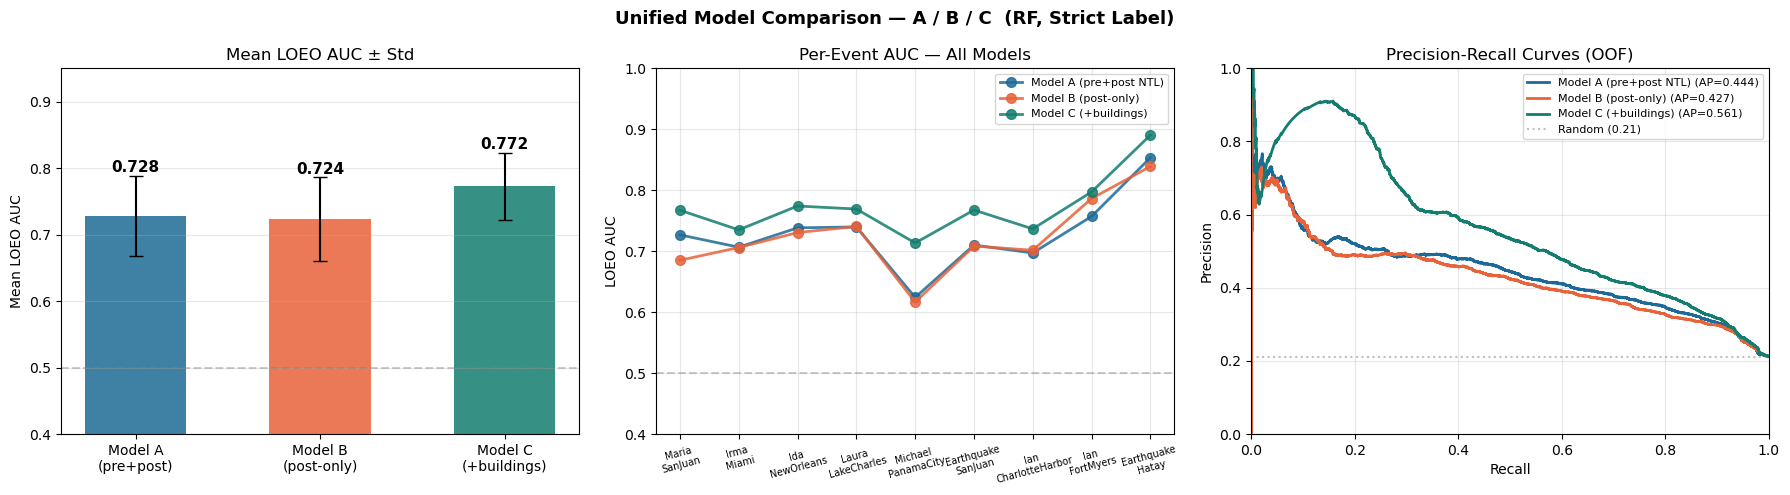

Saved → /Users/zhaozhiyuan/Documents/GitHub/Practicum/project/data/result/stage2/unified_comparison_ABC.png


In [198]:
# ── Unified visualisation: LOEO AUC + PR curves for A/B/C ────────────────────
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Unified Model Comparison — A / B / C  (RF, Strict Label)",
             fontsize=13, fontweight="bold")

colors = {"Model A (pre+post NTL)": "#1d6a96",
          "Model B (post-only)":    "#e8623a",
          "Model C (+buildings)":   "#147D6F"}

loeo_files = {
    "Model A (pre+post NTL)": "loeo_strict.csv",
    "Model B (post-only)":    "loeo_modelB.csv",
    "Model C (+buildings)":   "loeo_modelC.csv",
}

# ── Left: mean LOEO AUC bar ────────────────────────────────────────────────────
ax = axes[0]
for i, (name, fname) in enumerate(loeo_files.items()):
    ld   = pd.read_csv(os.path.join(OUTPUT_DIR, fname))
    mean = ld["rf_auc"].mean()
    std  = ld["rf_auc"].std()
    bar  = ax.bar(i, mean, yerr=std, color=colors[name],
                  alpha=0.85, capsize=5, width=0.55)
    ax.text(i, mean + std + 0.005, f"{mean:.3f}",
            ha="center", fontsize=11, fontweight="bold")

ax.axhline(0.5, ls="--", color="gray", alpha=0.4)
ax.set_xticks(range(3))
ax.set_xticklabels(["Model A\n(pre+post)", "Model B\n(post-only)",
                    "Model C\n(+buildings)"], fontsize=10)
ax.set_ylabel("Mean LOEO AUC")
ax.set_title("Mean LOEO AUC ± Std")
ax.set_ylim(0.4, 0.95)
ax.grid(axis="y", alpha=0.3)

# ── Middle: per-event AUC line plot ───────────────────────────────────────────
ax = axes[1]
loeo_a_df = pd.read_csv(os.path.join(OUTPUT_DIR, "loeo_strict.csv"))
events_ordered = loeo_a_df["held_out"].tolist()
x = np.arange(len(events_ordered))

for name, fname in loeo_files.items():
    ld   = pd.read_csv(os.path.join(OUTPUT_DIR, fname))
    aucs = []
    for ev in events_ordered:
        row = ld[ld["held_out"] == ev]
        aucs.append(row["rf_auc"].values[0] if not row.empty else np.nan)
    ax.plot(x, aucs, "o-", color=colors[name], linewidth=2,
            markersize=7, label=name, alpha=0.85)

ax.axhline(0.5, ls="--", color="gray", alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([e.replace("_","\n") for e in events_ordered],
                   fontsize=7, rotation=15)
ax.set_ylabel("LOEO AUC")
ax.set_title("Per-Event AUC — All Models")
ax.legend(fontsize=8)
ax.set_ylim(0.4, 1.0)
ax.grid(alpha=0.3)

# ── Right: PR curves ──────────────────────────────────────────────────────────
ax = axes[2]
for name, df_m, feats, oof_col, _ in [
    ("Model A (pre+post NTL)", df,   features,   "oof_A",  None),
    ("Model B (post-only)",    df_b, features_b, "oof_B",  None),
    ("Model C (+buildings)",   df_c, features_c, "oof_C",  None),
]:
    valid  = df_m[oof_col].notna() & df_m["in_buffer_strict"].notna()
    y_true = df_m.loc[valid, "in_buffer_strict"].values
    y_prob = df_m.loc[valid, oof_col].values
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax.plot(rec, prec, color=colors[name], linewidth=2,
            label="{} (AP={:.3f})".format(name, ap))

baseline = df["in_buffer_strict"].mean()
ax.axhline(baseline, ls=":", color="gray", alpha=0.5,
           label="Random ({:.2f})".format(baseline))
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves (OOF)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "unified_comparison_ABC.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print("Saved → {}".format(out))


In [199]:
print("=" * 65)
print("Stage 2 complete. Output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    full = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(full) / 1024
    print(f"  {f:<45s} {size:8.1f} KB")
print("=" * 65)


Stage 2 complete. Output files:
  Earthquake_Hatay_prob_map.html                  1406.4 KB
  Earthquake_Hatay_prob_map.png                     96.2 KB
  Earthquake_Hatay_prob_map.tif                     27.5 KB
  Earthquake_Hatay_prob_map_ABC.png                 93.9 KB
  Earthquake_Hatay_prob_map_modelB.html           1233.9 KB
  Earthquake_Hatay_prob_map_modelB.png              41.6 KB
  Earthquake_Hatay_prob_map_modelB.tif               9.2 KB
  Earthquake_SanJuan_prob_map.html                1623.5 KB
  Earthquake_SanJuan_prob_map.png                  265.3 KB
  Earthquake_SanJuan_prob_map.tif                   21.9 KB
  Earthquake_SanJuan_prob_map_ABC.png              267.4 KB
  Earthquake_SanJuan_prob_map_modelB.html         1125.4 KB
  Earthquake_SanJuan_prob_map_modelB.png           108.9 KB
  Earthquake_SanJuan_prob_map_modelB.tif             7.4 KB
  Ian_CharlotteHarbor_prob_map.html                766.2 KB
  Ian_CharlotteHarbor_prob_map.png                 100.7 KB
  Ian_Ch